# Paper Plots

## Imports

In [1]:
import numpy as np
import emcee

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm, Normalize
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import ImageGrid

from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
import corner

from astropy import units as u
from astropy import constants
from astropy.units import Quantity

import scipy
from scipy import signal
from scipy.fft import fft, fftshift

import sys

import cmcrameri.cm as cmc
import corner
from tqdm import tqdm

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr
from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Configuration

Set all user-facing parameters here.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # results for all cases
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                        # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'             # output directory

# ── Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['low_dl_fr_0', 'high_dl_fr_0', 'low_dl_fr_20']  # sub-folder names under result_dir

nm_list_arr = [
    [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
    [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
    [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
]

dl_inds = [[3, 4, 5, 6], [10, 11, 12, 13], [3, 3, 3, 3]]  # delay indices per case (for DPS plots)

# ── Single-case selection (for Figures 5, 6, 7, 8, 9) ────────────────────────
case_idx = 2  # 0 = Case I, 1 = Case II, 2 = Case III

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes = 10   # number of foreground modes

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 100000  # number of Gibbs iterations
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn         = 10      # burn-in (%)

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Derived parameters

In [3]:
# freqs = np.linspace(100., 120., 120)[:Nfreqs]  # MHz
# lsts  = np.linspace(0., 1., Ntimes)            # hours

freqs = np.load(parent_dir+'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6
lsts = np.load(parent_dir+'res/npy_data/lsts_full.npy')[:Ntimes]

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op   = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# Systematics operator for the selected case
sys_modes_operator = sys_modes(
    freqs_Hz   = freqs * 1e6,
    times_sec  = lsts * 24. / (2. * np.pi) * 3600.,
    modes      = nm_list_arr[case_idx],
)

3 20
4 20
5 20
6 20


## Helper functions

In [4]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, labels=None, truths=None, burn=0, thin=1, fig=None,
    truths_label="Truth",
    extra_truths=None, extra_color="tab:green", extra_truths_label="Truth B",
    title=None, legend_loc="best",
    nsigma=3,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, labels=labels, truths=truths,
        truth_color="tab:red",
        quantiles=quantiles,
        levels=levels,
        fig=fig,
        show_titles=True, title_fmt=".3g",
        bins=100, smooth=2.0, color="C0",
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]
    legend_handles = []
    if truths is not None:
        legend_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        legend_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if legend_handles:
        ax0.legend(handles=legend_handles, loc=legend_loc, frameon=False)
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

## Plot specifications

In [5]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 24})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ffc8dd']
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# Tick helpers (frequency / delay-fringe-rate space)
freqs_mhz = freqs * u.MHz
xticklocs = [1, 10, 20, 30, 40, 50, 59]
yticklocs = [0, 10, 20, 30, 40, 50, 60, 70]

lsts_round   = np.array([round(l, 2) for l in lsts])
times        = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3  # mHz

xticks_dl   = delays[xticklocs]
yticks_fr   = fringe_rates[yticklocs]
xticklabels_dl = [str(int(round(val, 2))) for val in xticks_dl.value]
yticklabels_fr = [f'{val:.2f}' for val in yticks_fr]

---
# Figure 1: Data in visibility space

In [6]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-fgs.uvh5')
clean_vis  = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

uvd = UVData()
uvd.read(parent_dir + 'res/vis_corrupted_test.uvh5')
vis_corr   = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

# Tick setup for full-resolution arrays
freqs_mhz_full = freqs_full * u.MHz
times_full     = Quantity(lsts_full * 12 / np.pi, unit='h')
xticklocs_full = [1, 20, 40, 60, 80, 100, 119]
yticklocs_full = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
xticklabels_freqs_full = [str(int(val * 10e-7)) for val in freqs_mhz_full[xticklocs_full].value]
yticklabels_times_full = [str(round(val, 2))    for val in times_full[yticklocs_full].value]

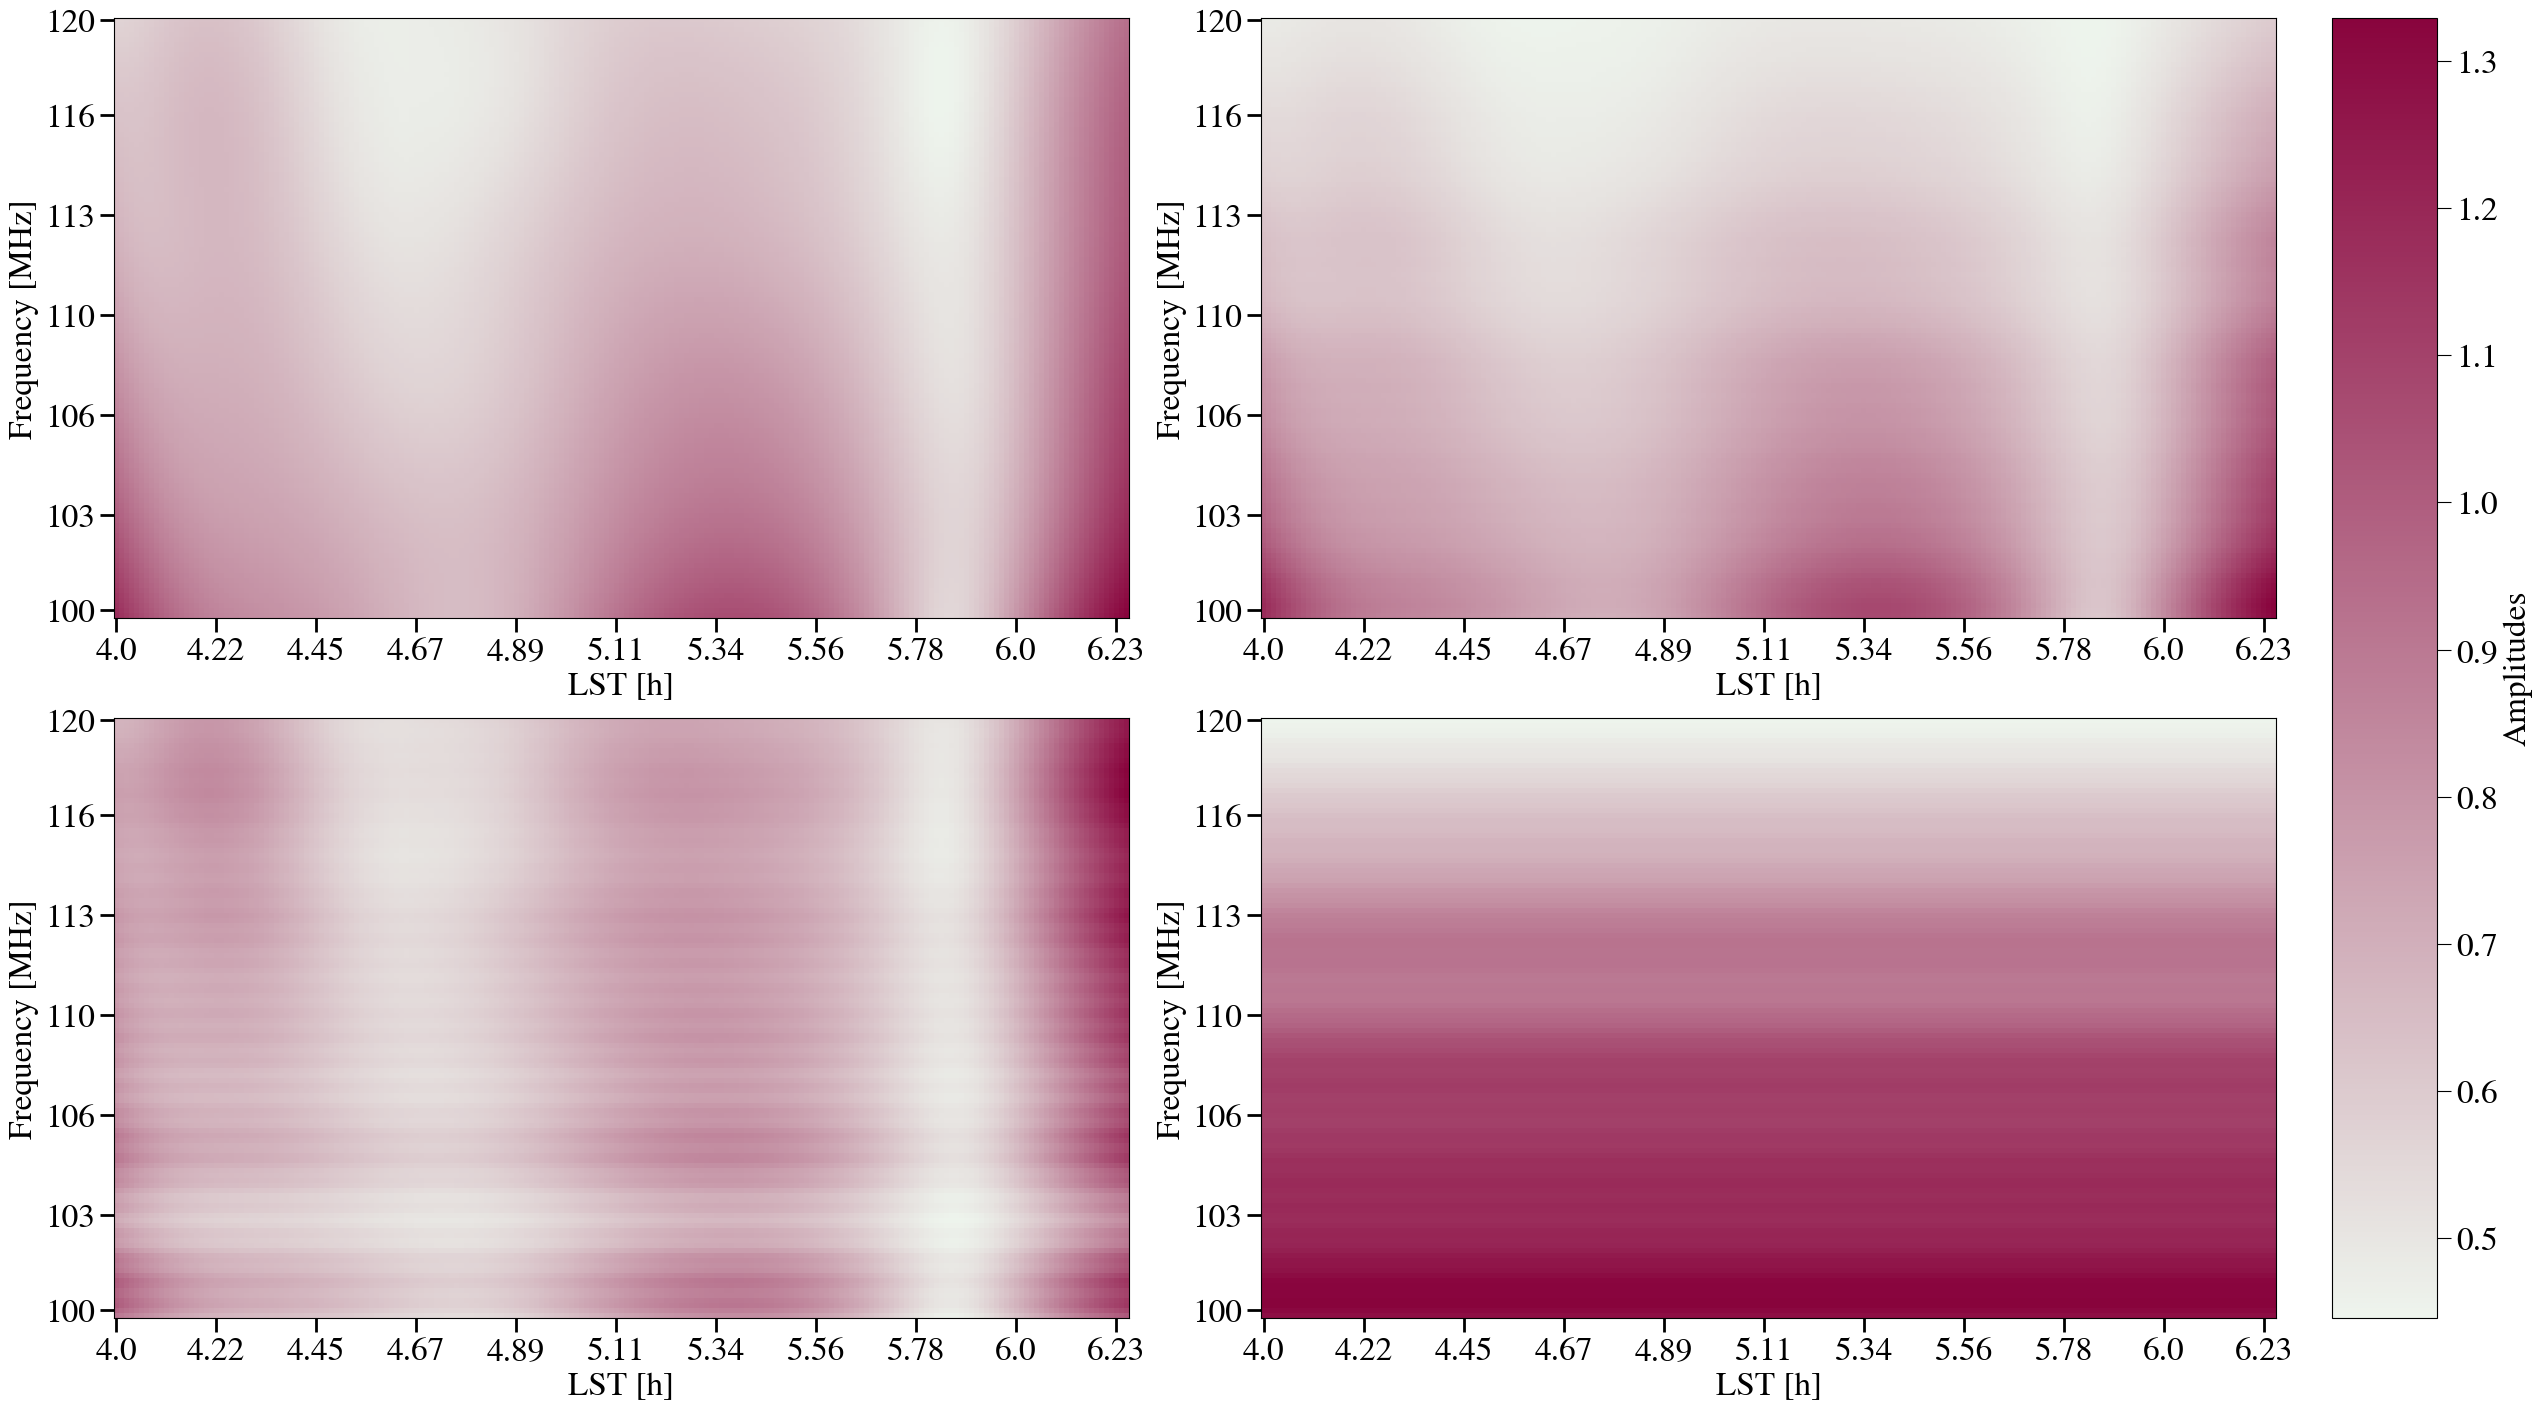

In [7]:
fig = plt.figure(figsize=(30., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.78, 0.65),
    nrows_ncols=(2, 2),
    axes_pad=1,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='all',
    aspect=False,
)
data_arr = np.array([[clean_vis, vis_corr], [vis_corr - clean_vis, vis_corr / clean_vis]])
a = 0
for i in range(2):
    for j in range(2):
        im = axs[a].imshow(np.abs(data_arr[i, j, :, :]).T, cmap=paper_map_pink, origin='lower')
        axs[a].set_ylabel('Frequency [MHz]')
        axs[a].set_xlabel('LST [h]')
        axs[a].tick_params(direction='out', length=6, width=2, colors='black', size=10)
        a += 1
cbar = axs.cbar_axes[0].colorbar(im, label='Amplitudes')
cbar.ax.tick_params(which='both', color='black', labelcolor='black', size=10)
for a in axs:
    a.set_yticks(xticklocs_full, labels=xticklabels_freqs_full)
    a.set_xticks(yticklocs_full, labels=yticklabels_times_full)
# plt.savefig(fig_dir + '/systematics_in_vis_space.pdf', bbox_inches='tight', dpi=300)

---
# Figure 3: Test cases in delay–fringe-rate space

In [8]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

eor_true = np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true  = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_full = eor_true + fg_true
data_true_dlfr_full = data_dly_fr(data_true_full, freqs * 1e6, lsts, windows='blackman-harris')

3 0
4 0
5 0
6 0
10 0
11 0
12 0
13 0
3 20
4 20
5 20
6 20


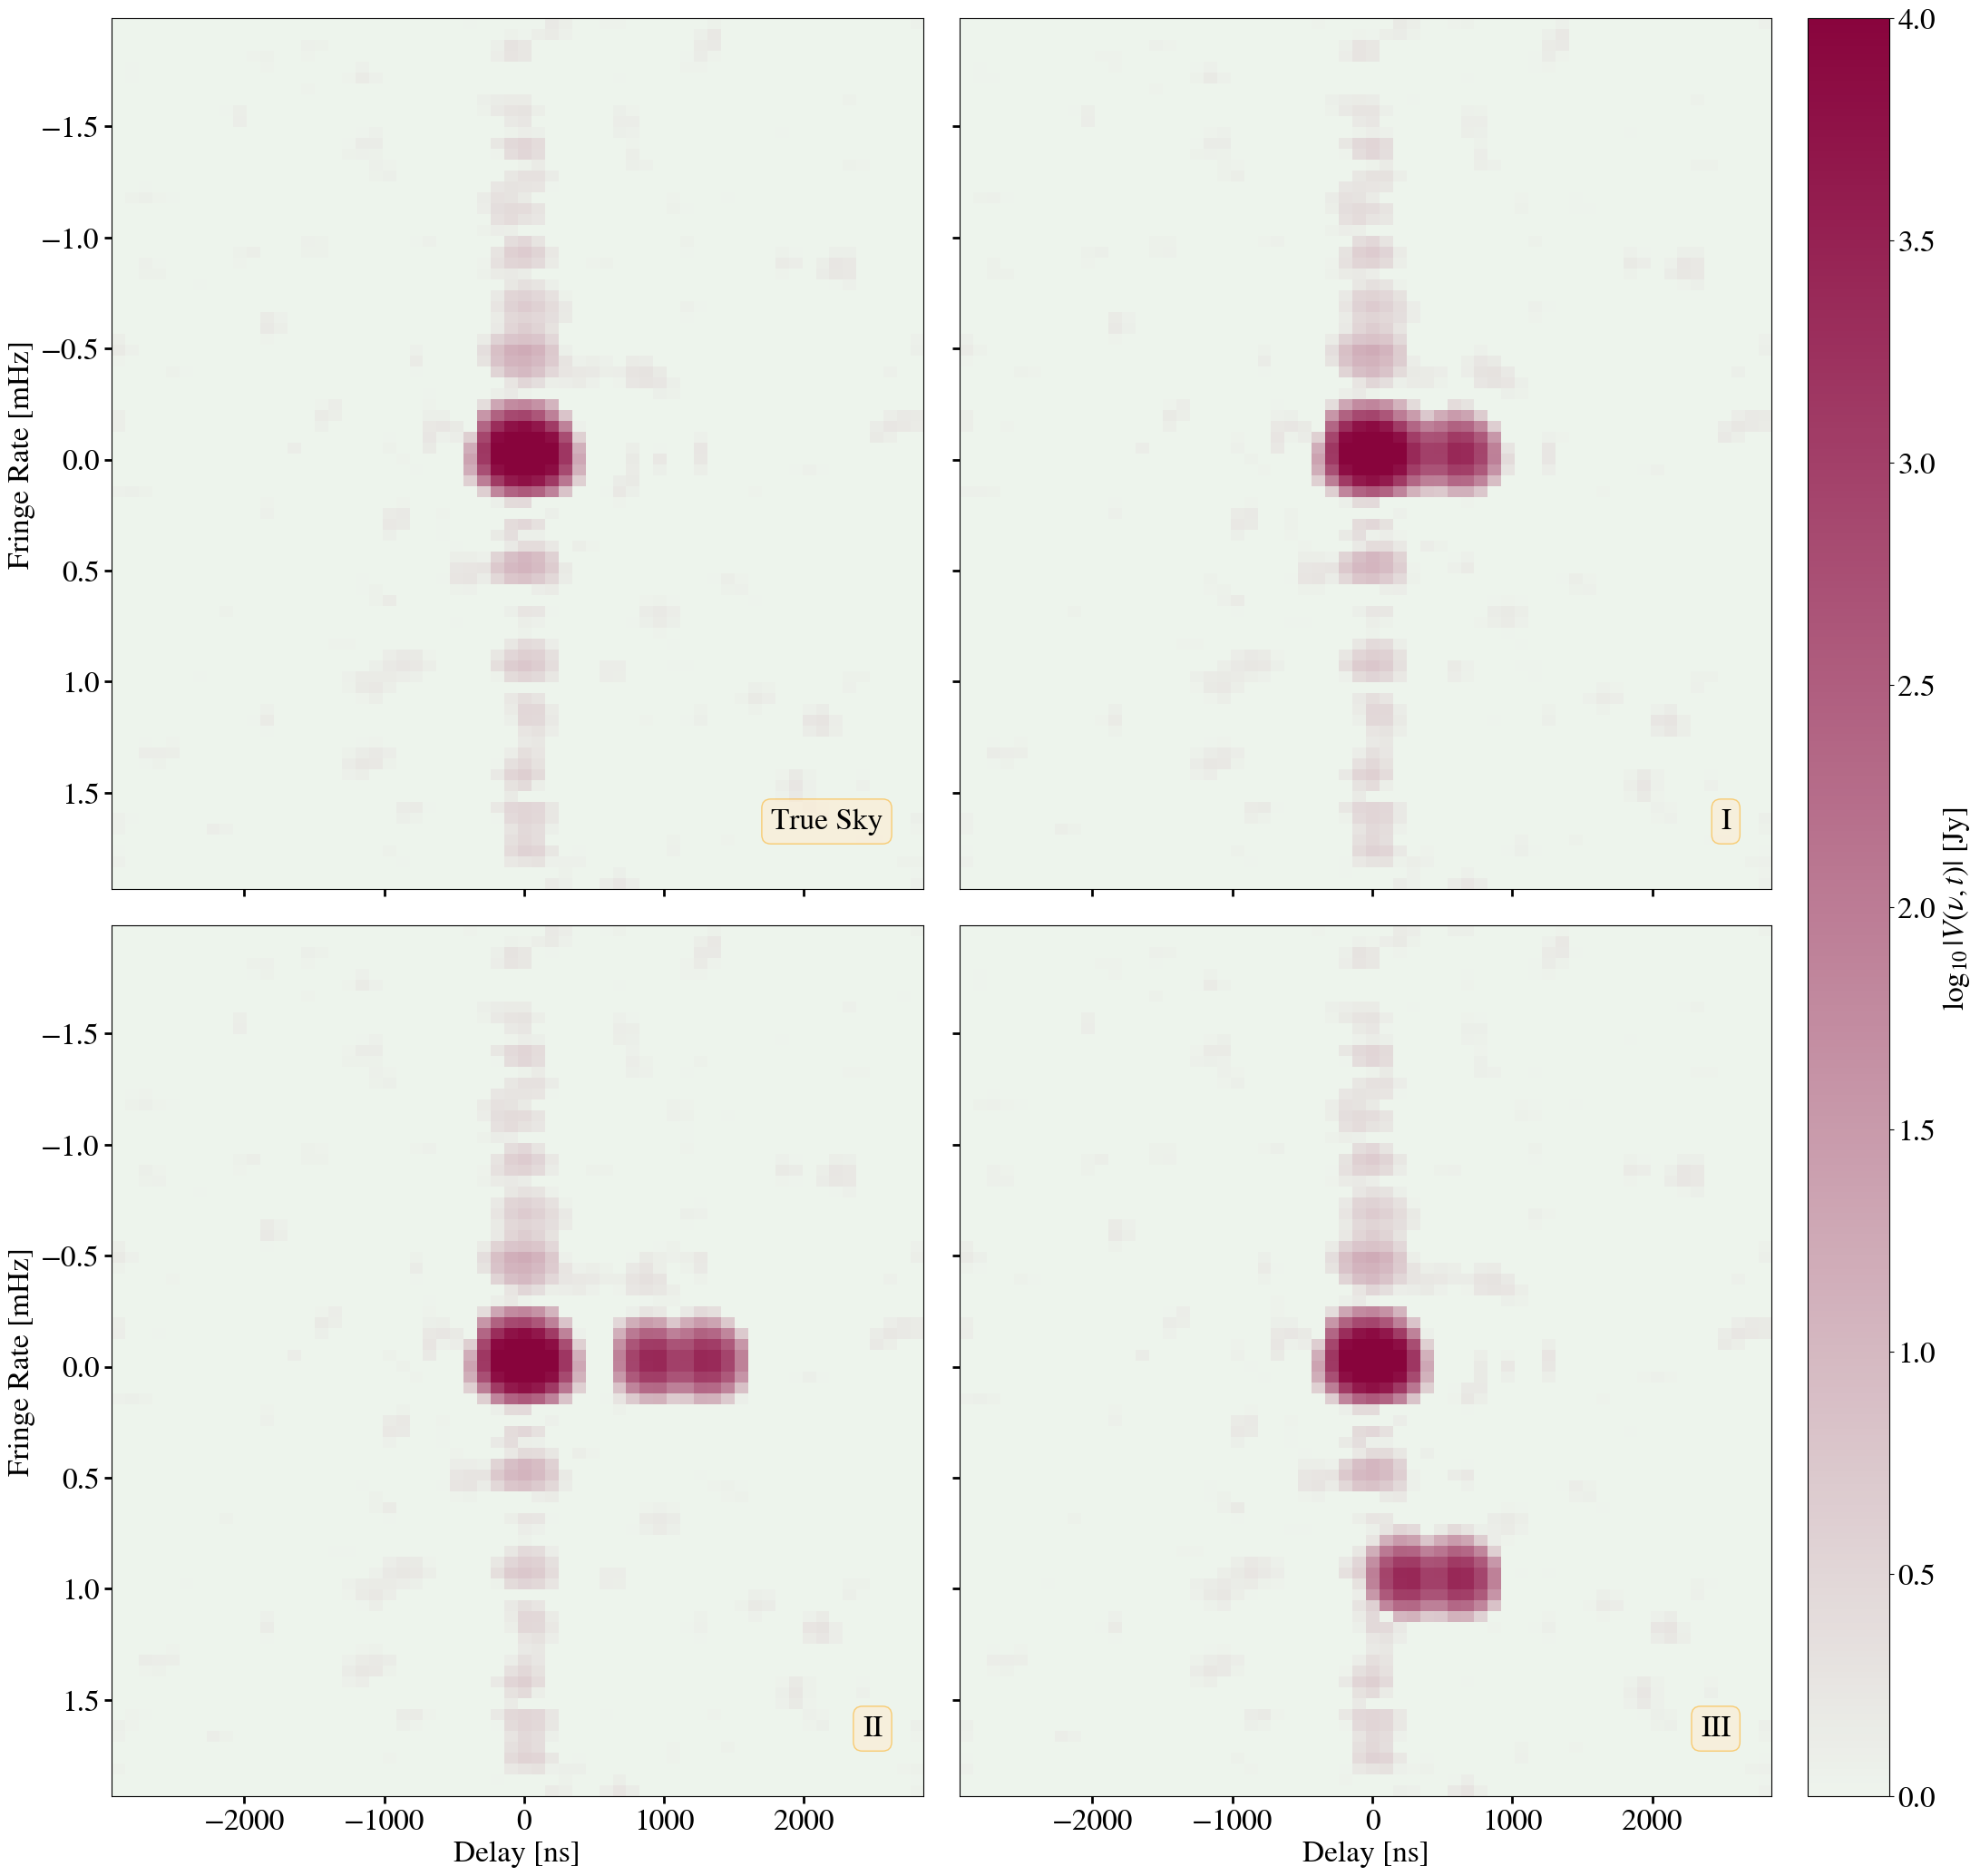

In [10]:
fig = plt.figure(figsize=(20., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 2),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls_from_dlfr(
    data_true_dlfr_full, freqs * 1e6, lsts, fig=fig, ax=axs[0], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all',
    baseline=None, horizon_color='magenta', colorbar_flag=False,
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

fig_labels = ['I', 'II', 'III']
for i, run_version in enumerate(run_version_arr):
    op = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts * 24. / (2. * np.pi) * 3600., modes=nm_list_arr[i])
    sys_model_true = (1 + op @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
    total_data_dlfr = data_dly_fr(sys_model_true * data_true_full, freqs * 1e6, lsts, windows='blackman-harris')
    plot_op = plot_waterfalls_from_dlfr(
        total_data_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs[i + 1], mode='log',
        vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=False,
        baseline=None, horizon_color='magenta',
    )
    axs[i + 1].text(0.95, 0.07, fig_labels[i], bbox=bbox, transform=axs[i + 1].transAxes, horizontalalignment='right')

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|V(\nu, t)|$ [Jy]')
plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)

---
# Single-case analysis (case_idx = `case_idx`)

The cells below load and process data for the single case selected by `case_idx`.

In [11]:
run_version = run_version_arr[case_idx]

fg_true       = np.load(result_dir + run_version + '/fg_true.npy')
fgmodes       = np.load(result_dir + run_version + '/fgmodes.npy')
fg_amps_gcr   = np.load(result_dir + run_version + '/fg-amps.npy')
eor_true      = np.load(result_dir + run_version + '/eor_true.npy')
eor_gcr       = np.load(result_dir + run_version + '/gcr-eor.npy')
ps_sample     = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post       = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr     = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
data_true     = np.load(result_dir + run_version + '/data_true.npy')

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# Power spectra
ps_fg    = np.empty(ps_sample.shape)
ps_sys   = np.empty(ps_sample.shape)
ps_del_g = np.empty(ps_sample.shape)
ps_data  = np.empty(ps_sample.shape)

for i in tqdm(range(Niter)):
    sys_model = (sys_modes_operator @ b_sys_gcr[i, :]).reshape([Nfreqs, Ntimes]).T
    data_model = (1 + sys_model) * (eor_gcr[i, :, :] + (fgmodes @ fg_amps_gcr[i, :].T).T)
    ps_data[i]  = calc_ps(data_model)
    ps_fg[i]    = calc_ps((fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i, :].T).T)
    ps_sys[i]   = calc_ps(1 + sys_model)
    ps_del_g[i] = calc_ps(sys_model)

eor_pspec_avg  = np.mean(ps_sample, axis=0)
fg_pspec_avg   = np.mean(ps_fg, axis=0)
sys_pspec_avg  = np.mean(ps_sys, axis=0)
data_pspec_avg = np.mean(ps_data, axis=0)
delg_pspec_avg = np.mean(ps_del_g, axis=0)

eor_pspec_true  = calc_ps(eor_true)
fg_pspec_true   = calc_ps(fg_true)
sys_pspec_true  = calc_ps(sys_model_true)
n_pspec         = calc_ps(n.T)
data_pspec_true = calc_ps(data_true)
b_sys_mean      = np.mean(b_sys_gcr, axis=0)

# DLFR representations
sky_true_dlfr       = data_dly_fr(sky_true,       freqs * 1e6, lsts, windows='blackman-harris')
sys_model_true_dlfr = data_dly_fr(sys_model_true, freqs * 1e6, lsts, windows='blackman-harris')
delta_g_dlfr_true   = data_dly_fr(delta_g_true,   freqs * 1e6, lsts, windows='blackman-harris')
data_true_dlfr      = data_dly_fr(data_true,       freqs * 1e6, lsts, windows='blackman-harris')

100%|██████████| 100000/100000 [00:57<00:00, 1729.99it/s]


In [12]:
# Sample-by-sample model arrays
fg_vis_arr           = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
delta_g_arr          = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
eor_dlfr_arr         = np.empty(eor_gcr.shape, dtype='complex')
sky_dlfr_arr         = np.empty(eor_gcr.shape, dtype='complex')
delta_g_dlfr_arr     = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
sys_model_dlfr_arr   = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')

print('Foregrounds...')
for i in tqdm(range(fg_amps_gcr.shape[0])):
    fg_vis_arr[i, :, :] = (fgmodes @ fg_amps_gcr[i, :].T).T

print('Sky DLFR...')
for i in tqdm(range(len(eor_gcr))):
    eor_dlfr_arr[i, :, :] = data_dly_fr(eor_gcr[i, :, :], freqs * 1e6, lsts, windows='blackman-harris')
    sky_dlfr_arr[i, :, :] = data_dly_fr(
        eor_gcr[i, :, :] + fg_vis_arr[i, :, :], freqs * 1e6, lsts, windows='blackman-harris',
    )
print('Systematics...')
for i in tqdm(range(Niter)):
    delta_g_arr[i, :, :]        = (sys_modes_operator @ b_sys_gcr[i, :]).reshape([Nfreqs, Ntimes]).T
    delta_g_dlfr_arr[i, :, :]   = data_dly_fr(delta_g_arr[i, :, :],       freqs * 1e6, lsts, windows='blackman-harris')
    sys_model_dlfr_arr[i, :, :] = data_dly_fr(1 + delta_g_arr[i, :, :],   freqs * 1e6, lsts, windows='blackman-harris')

delta_g_dlfr_mean  = delta_g_dlfr_arr.mean(axis=0)
delta_g_dlfr_std   = np.std(delta_g_dlfr_arr, axis=0)
delta_g_mean       = delta_g_arr.mean(axis=0)
delta_g_std        = np.std(delta_g_arr, axis=0)
sys_model_dlfr_mean = sys_model_dlfr_arr.mean(axis=0)
mean_sky_dlfr      = sky_dlfr_arr.mean(axis=0)
mean_eor_dlfr      = eor_dlfr_arr.mean(axis=0)

Foregrounds...


100%|██████████| 100000/100000 [00:02<00:00, 38975.01it/s]


Sky DLFR...


100%|██████████| 100000/100000 [00:28<00:00, 3488.40it/s]


Systematics...


100%|██████████| 100000/100000 [01:54<00:00, 872.81it/s]


---
# Figure 4: Data vs sky (all cases)

3 0
4 0
5 0
6 0
Foregrounds...


100%|██████████| 100000/100000 [00:02<00:00, 38671.81it/s]


Sky DLFR...


100%|██████████| 100000/100000 [00:28<00:00, 3477.33it/s]


Systematics...


...

100%|██████████| 100000/100000 [00:02<00:00, 38718.61it/s]


Sky DLFR...


100%|██████████| 100000/100000 [00:28<00:00, 3494.08it/s]


Systematics...


100%|██████████| 100000/100000 [00:59<00:00, 1693.37it/s]


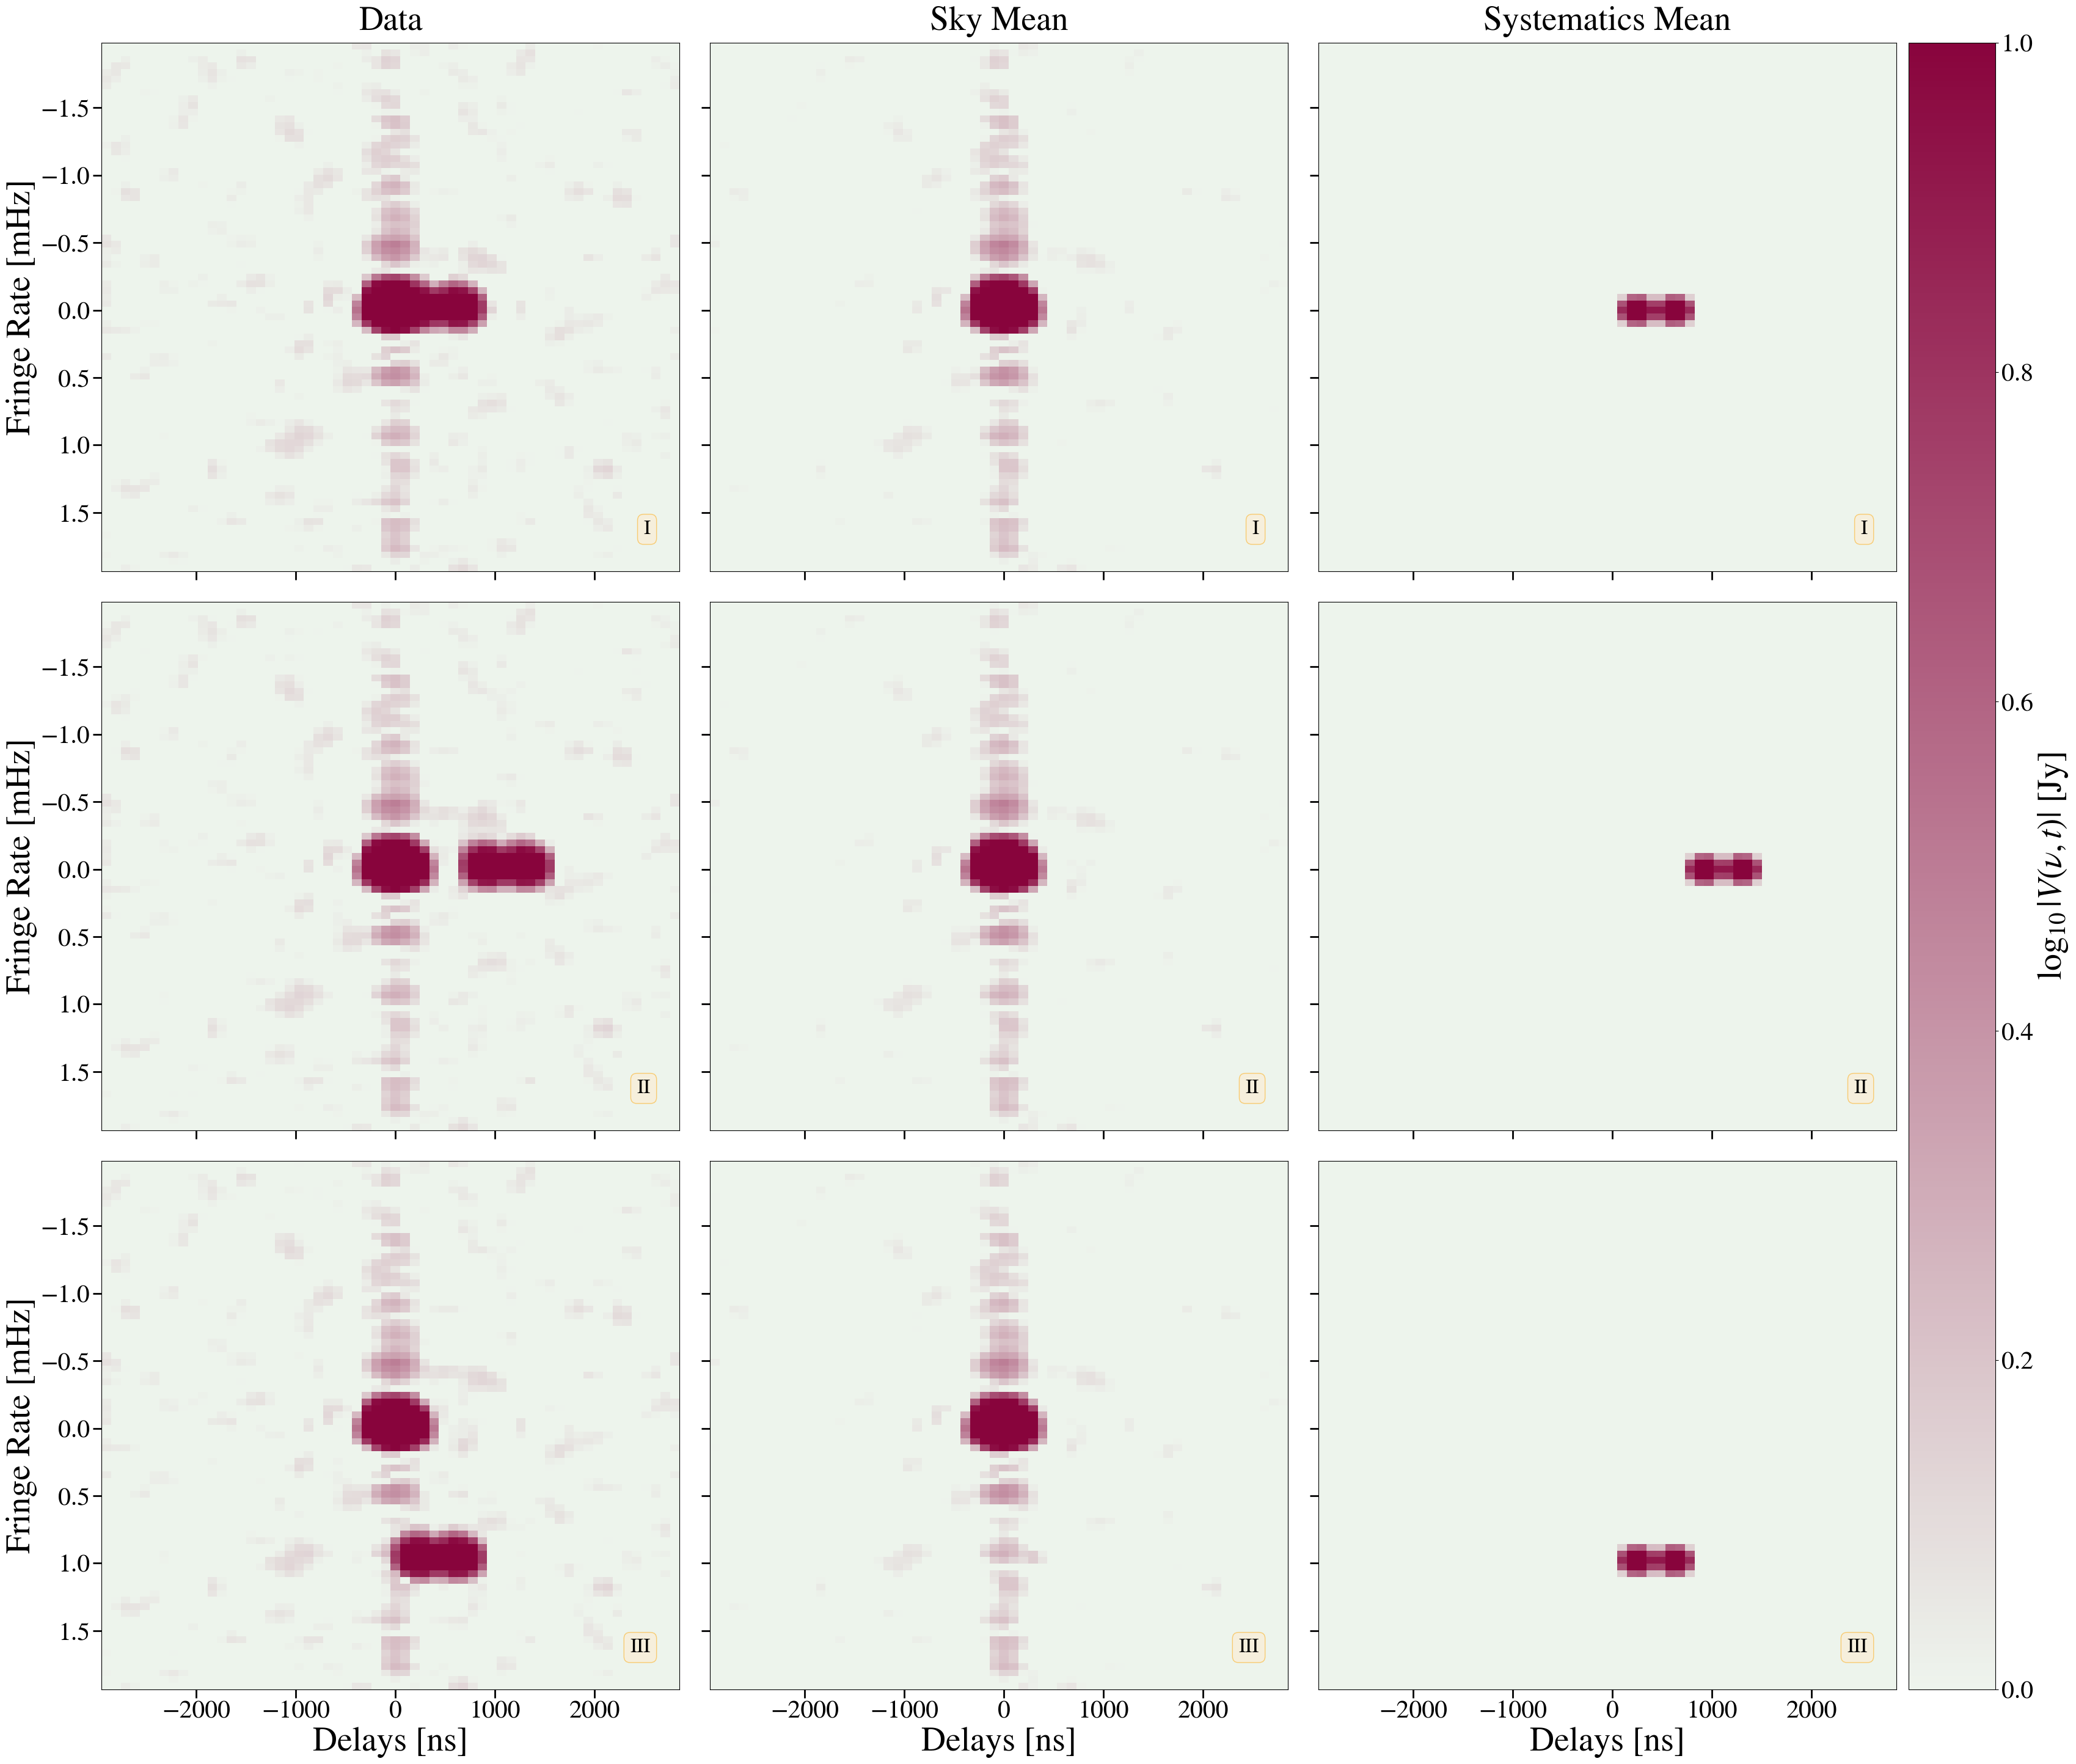

In [13]:
fig = plt.figure(figsize=(40, 35))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(3, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

c = 0
for a in range(3):
    op_a = sys_modes(
        freqs_Hz=freqs * 1e6, times_sec=lsts * 24. / (2. * np.pi) * 3600., modes=nm_list_arr[a],
    )
    fg_amps_a   = np.load(result_dir + run_version_arr[a] + '/fg-amps.npy')
    eor_gcr_a   = np.load(result_dir + run_version_arr[a] + '/gcr-eor.npy')
    b_sys_a     = np.load(result_dir + run_version_arr[a] + '/b-sys.npy')
    data_true_a = np.load(result_dir + run_version_arr[a] + '/data_true.npy')
    delta_g_true_a = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T

    data_true_dlfr_a = data_dly_fr(data_true_a, freqs * 1e6, lsts, windows='blackman-harris')

    fg_vis_a          = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    delta_g_a         = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    eor_dlfr_a        = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    sky_dlfr_a        = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    delta_g_dlfr_a    = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    sys_model_dlfr_a  = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')

    fgmodes_a = np.load(result_dir + run_version_arr[a] + '/fgmodes.npy')
    print('Foregrounds...')
    for i in tqdm(range(Niter)):
        fg_vis_a[i, :, :] = (fgmodes_a @ fg_amps_a[i, :].T).T

    print('Sky DLFR...')
    for i in tqdm(range(Niter)):
        eor_dlfr_a[i, :, :] = data_dly_fr(eor_gcr_a[i, :, :], freqs * 1e6, lsts, windows='blackman-harris')
        sky_dlfr_a[i, :, :] = data_dly_fr(
            eor_gcr_a[i, :, :] + fg_vis_a[i, :, :], freqs * 1e6, lsts, windows='blackman-harris',
        )

    print('Systematics...')
    for i in tqdm(range(Niter)):
        delta_g_a[i, :, :]       = (op_a @ b_sys_a[i, :]).reshape([Nfreqs, Ntimes]).T
        delta_g_dlfr_a[i, :, :]  = data_dly_fr(delta_g_a[i, :, :],     freqs * 1e6, lsts, windows='blackman-harris')
        sys_model_dlfr_a[i, :, :] = data_dly_fr(1 + delta_g_a[i, :, :], freqs * 1e6, lsts, windows='blackman-harris')

    delta_g_dlfr_mean_a = delta_g_dlfr_a.mean(axis=0)
    mean_sky_dlfr_a     = sky_dlfr_a.mean(axis=0)

    im0 = plot_waterfalls_from_dlfr(
        data_true_dlfr_a, freqs * 1e6, lsts, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1
    im1 = plot_waterfalls_from_dlfr(
        mean_sky_dlfr_a, freqs * 1e6, lsts, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1
    im2 = plot_waterfalls_from_dlfr(
        delta_g_dlfr_mean_a, freqs * 1e6, lsts, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1

fig_labels_all = ['I'] * 3 + ['II'] * 3 + ['III'] * 3
fig_titles     = ['Data', 'Sky Mean', 'Systematics Mean']
for i, a in enumerate(ax):
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=30)
    a.set_xlabel('Delays [ns]', fontsize=40)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=40)
    a.text(0.95, 0.07, fig_labels_all[i], bbox=bbox, transform=a.transAxes, horizontalalignment='right')
for i, a in enumerate(ax[:3]):
    a.set_title(fig_titles[i], fontsize=40, pad=15)
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(r'$\log_{10}|V(\nu, t)|$ [Jy]', size=40)
cbar.ax.tick_params(labelsize=30)
plt.savefig(fig_dir + '/data_vs_sky_2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5: Result waterfalls (single case)

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

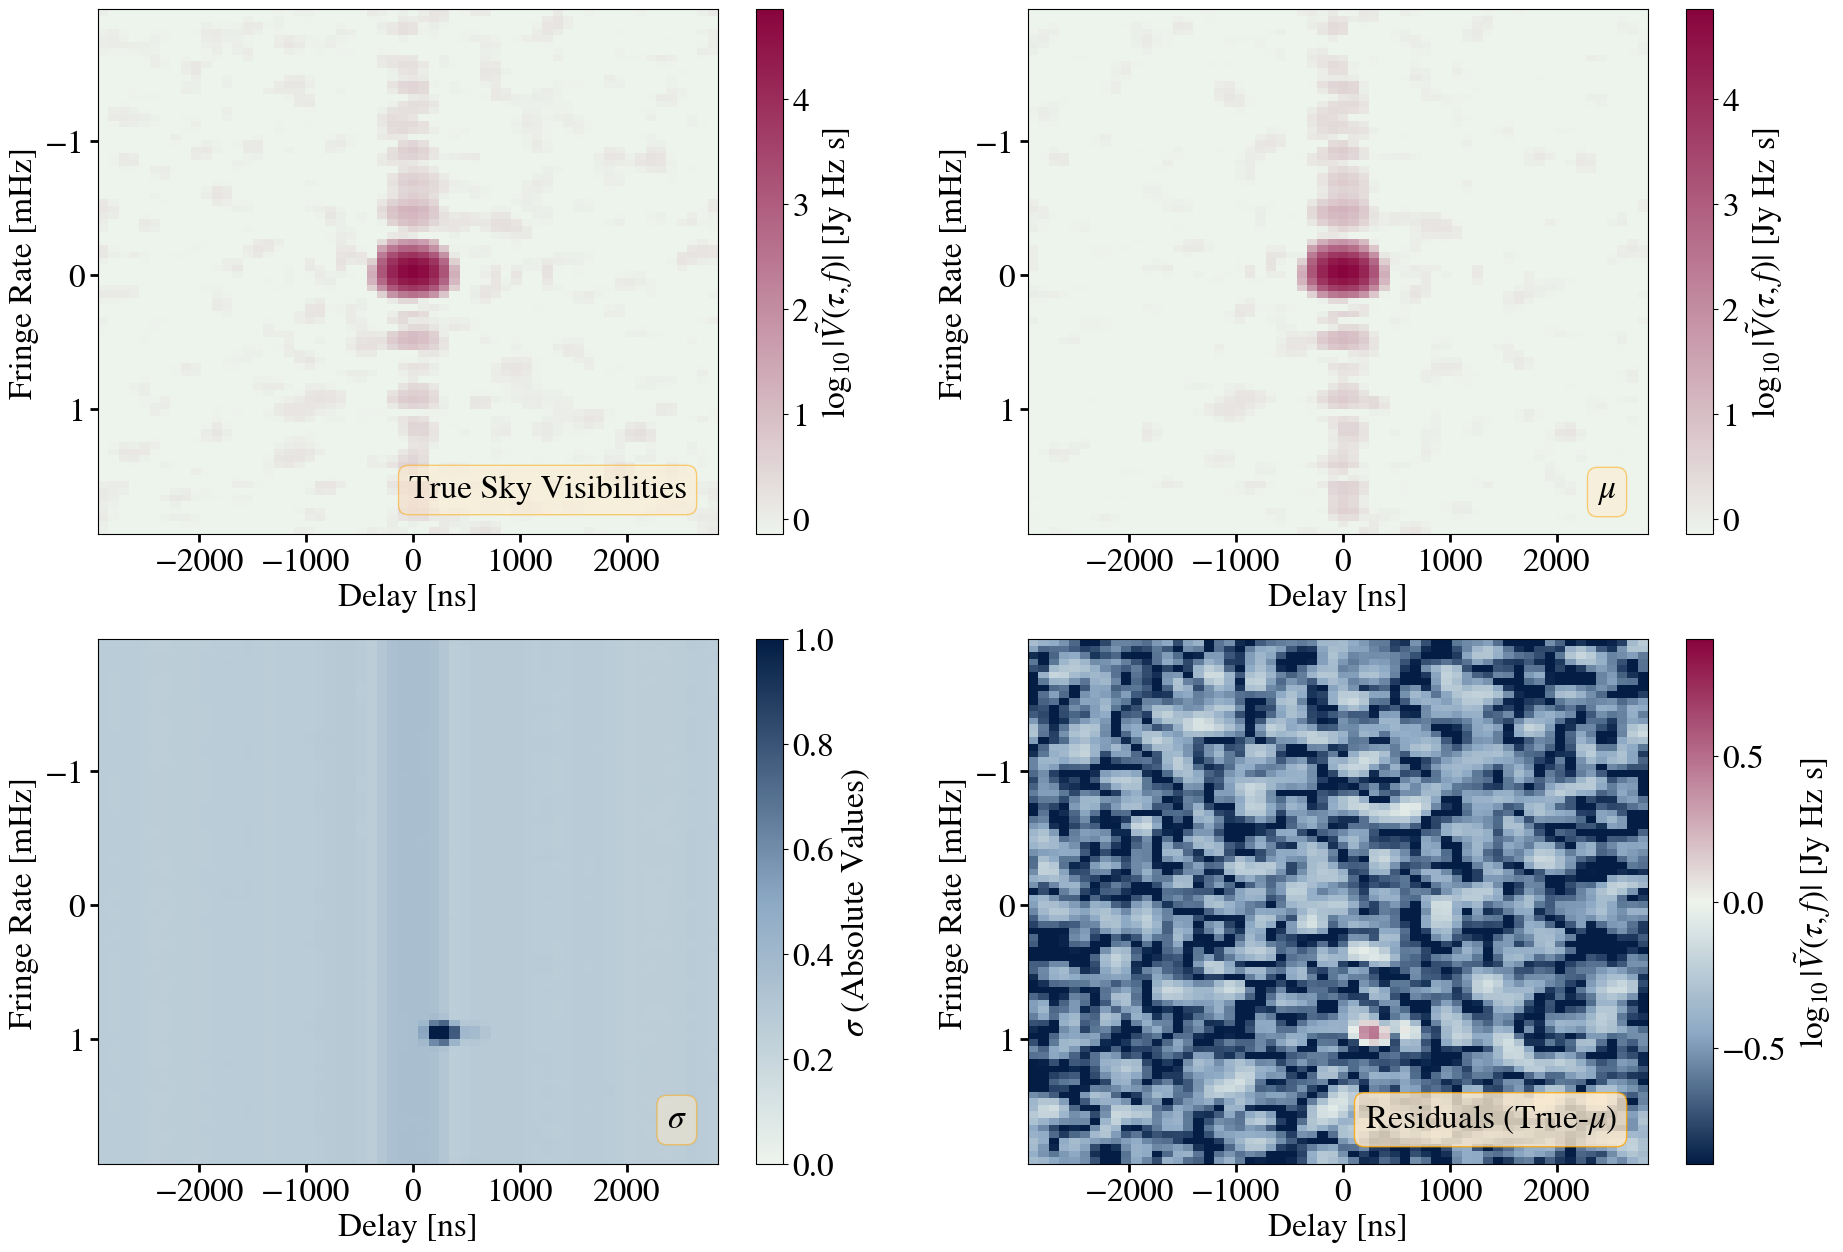

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Sky Visibilities', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    np.std(sky_dlfr_arr, axis=0), freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sky_true_dlfr - mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir + '/result_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5v2: Result waterfalls (all cases)

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

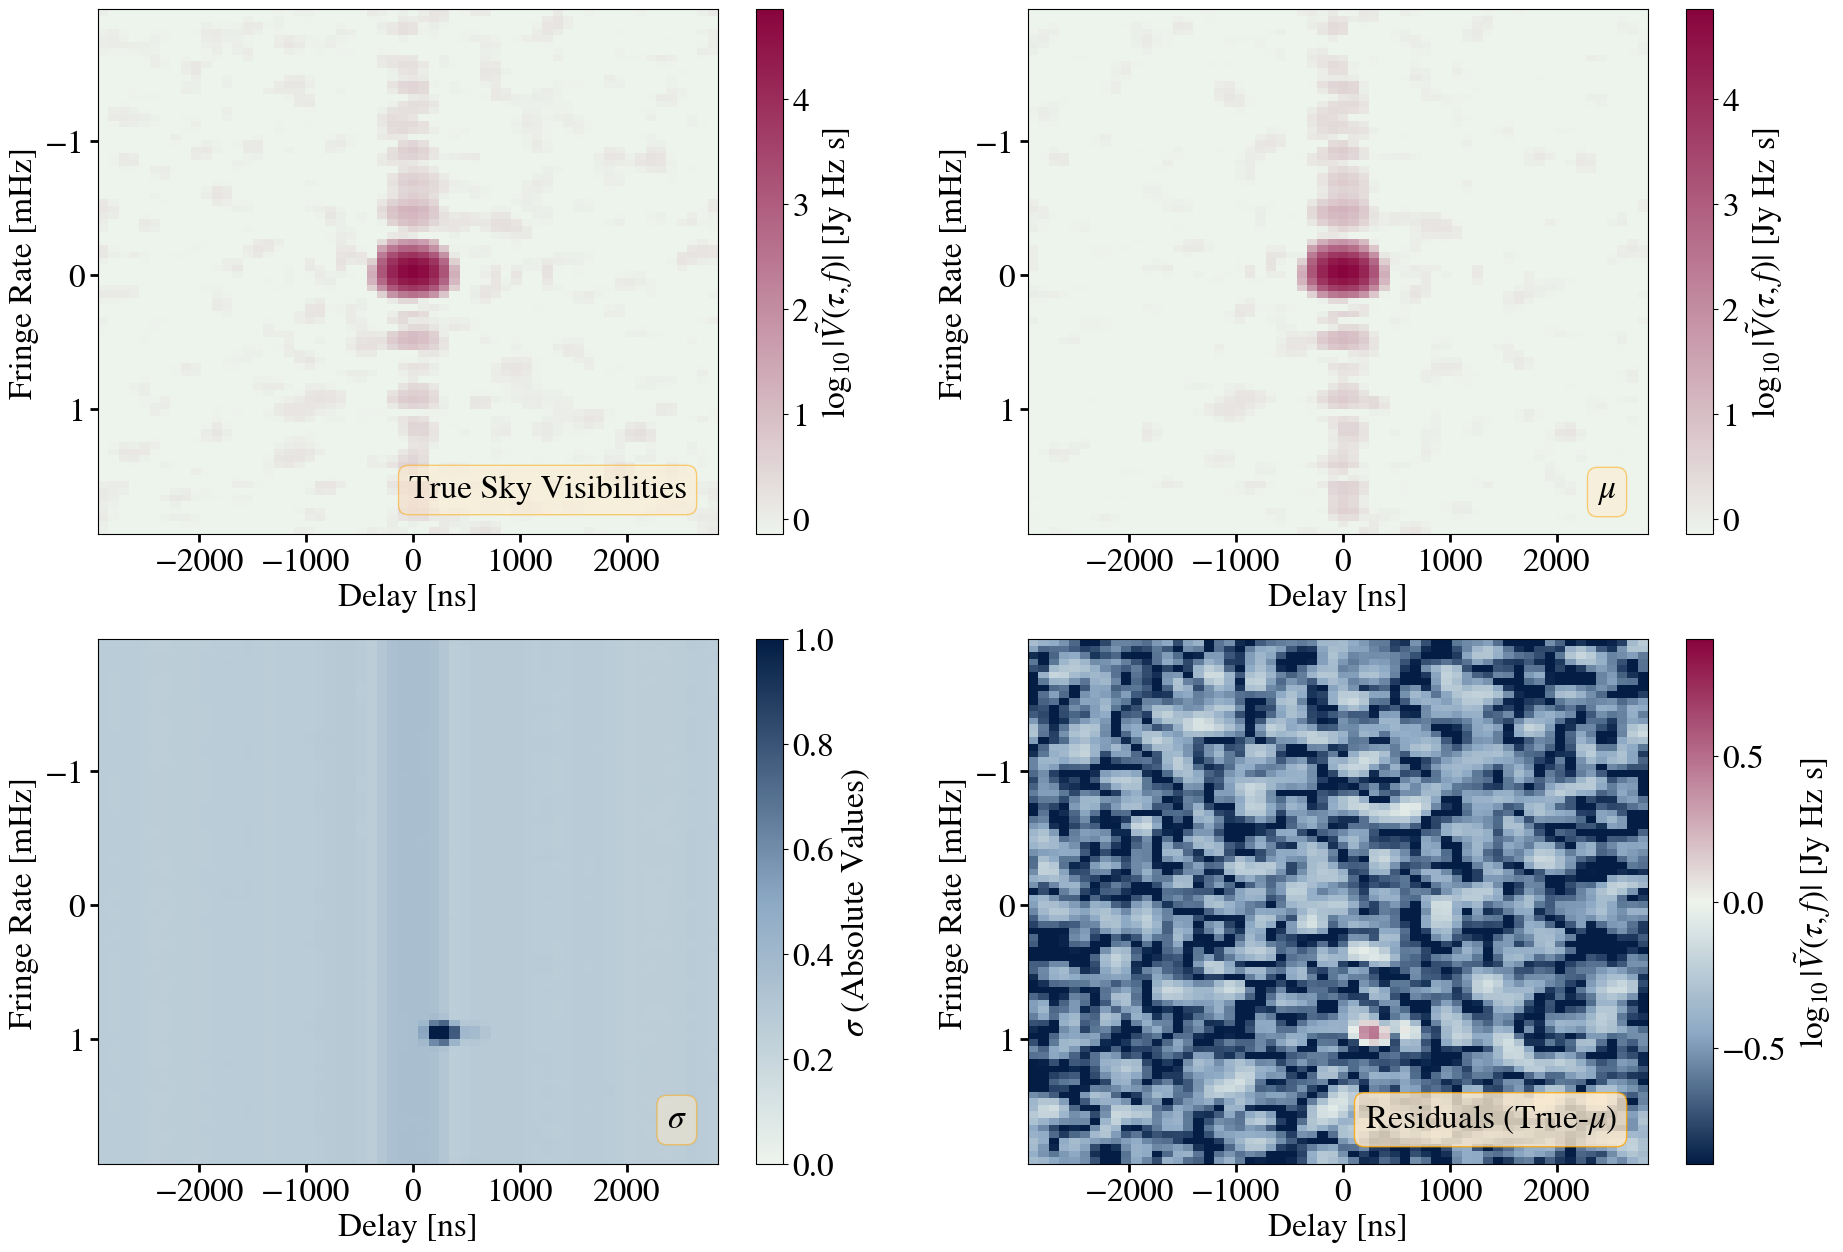

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(45, 40))

plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Sky Visibilities', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    np.std(sky_dlfr_arr, axis=0), freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sky_true_dlfr - mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir + '/result_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figure 6: Systematics result waterfalls (single case)

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

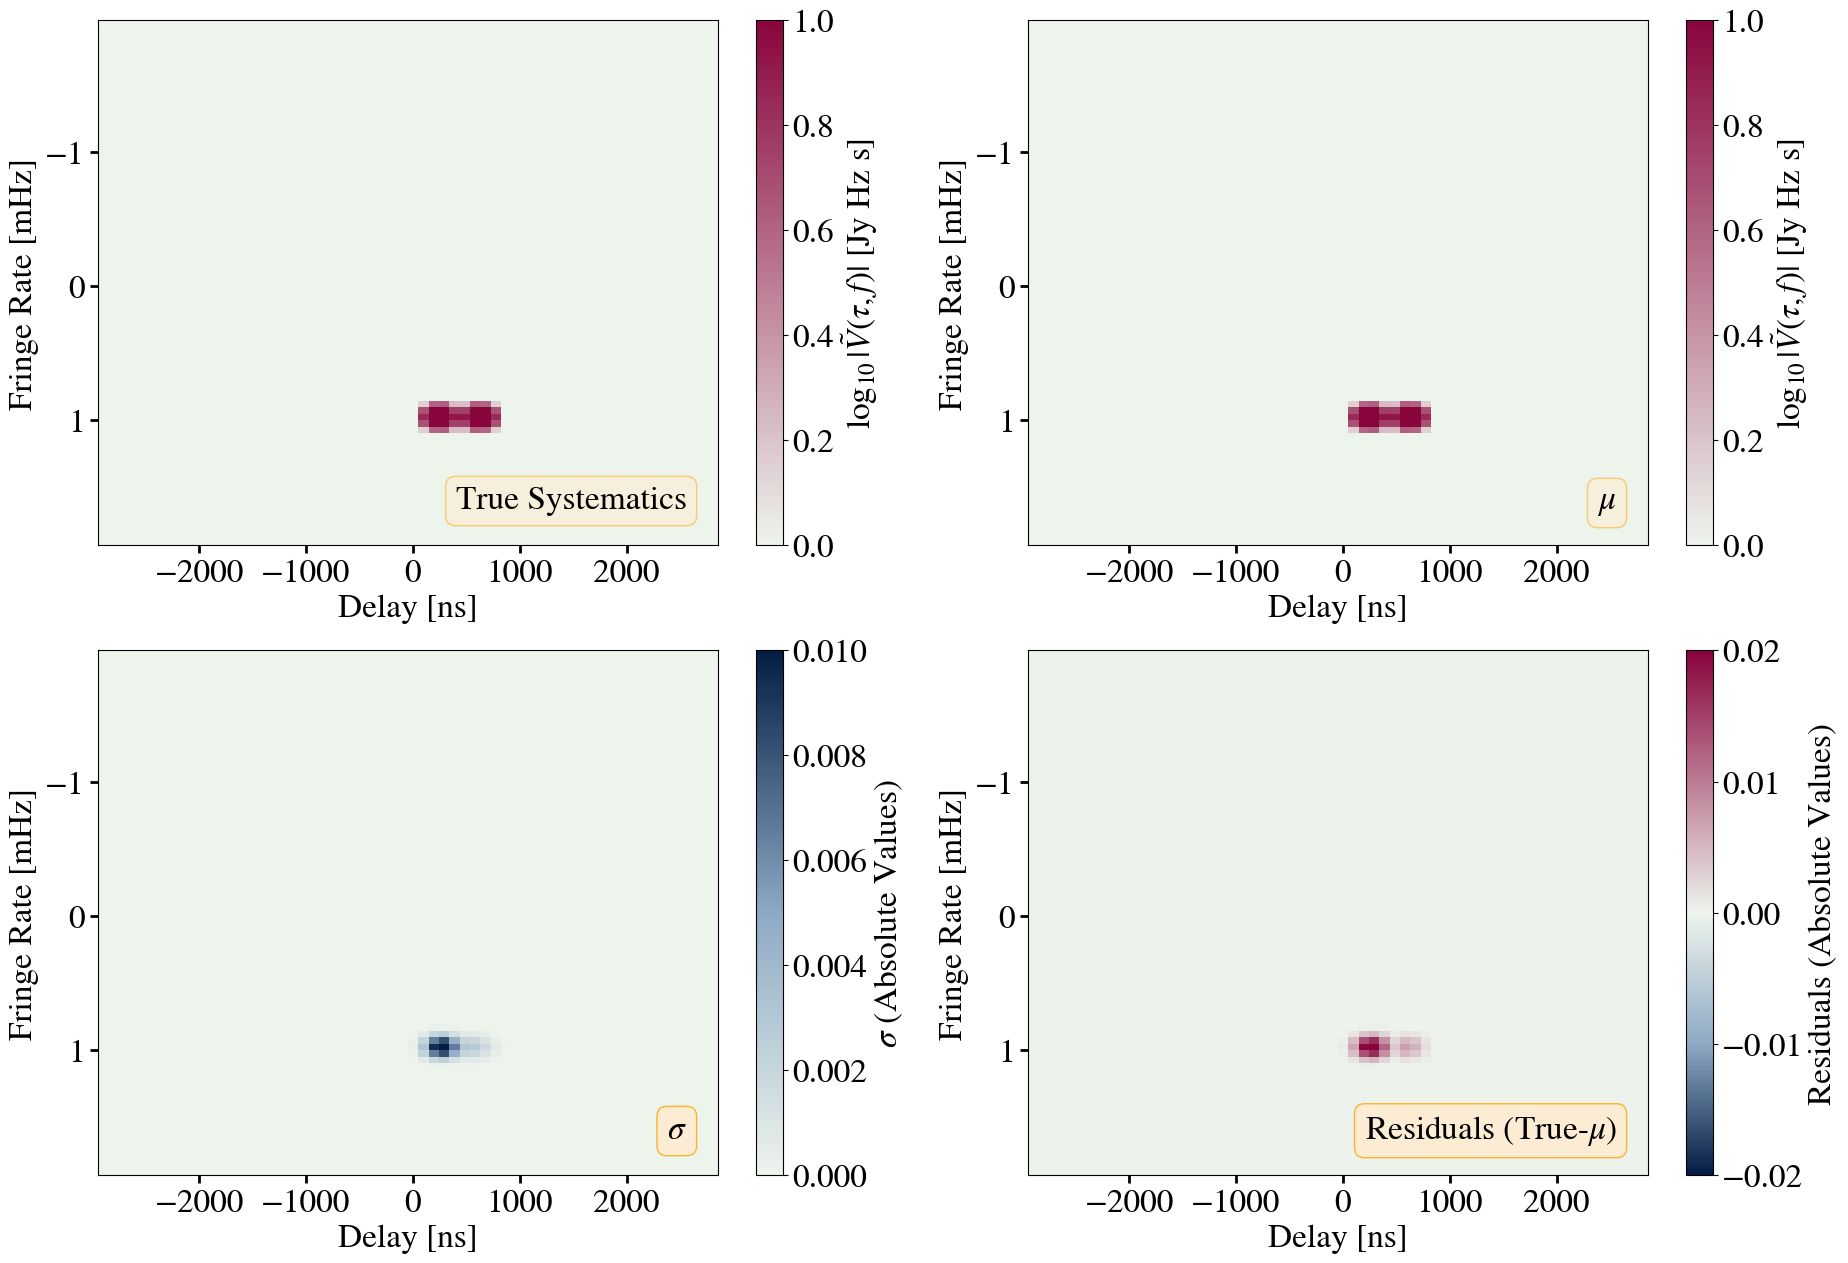

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    delta_g_dlfr_true, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Systematics', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_std, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sys_model_true_dlfr - sys_model_dlfr_arr.mean(axis=0), freqs * 1e6, lsts,
    fig=fig, ax=axs.flatten()[3], mode='abs', vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label='Residuals (Absolute Values)',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figure 7: Fractional errors by component (single case)

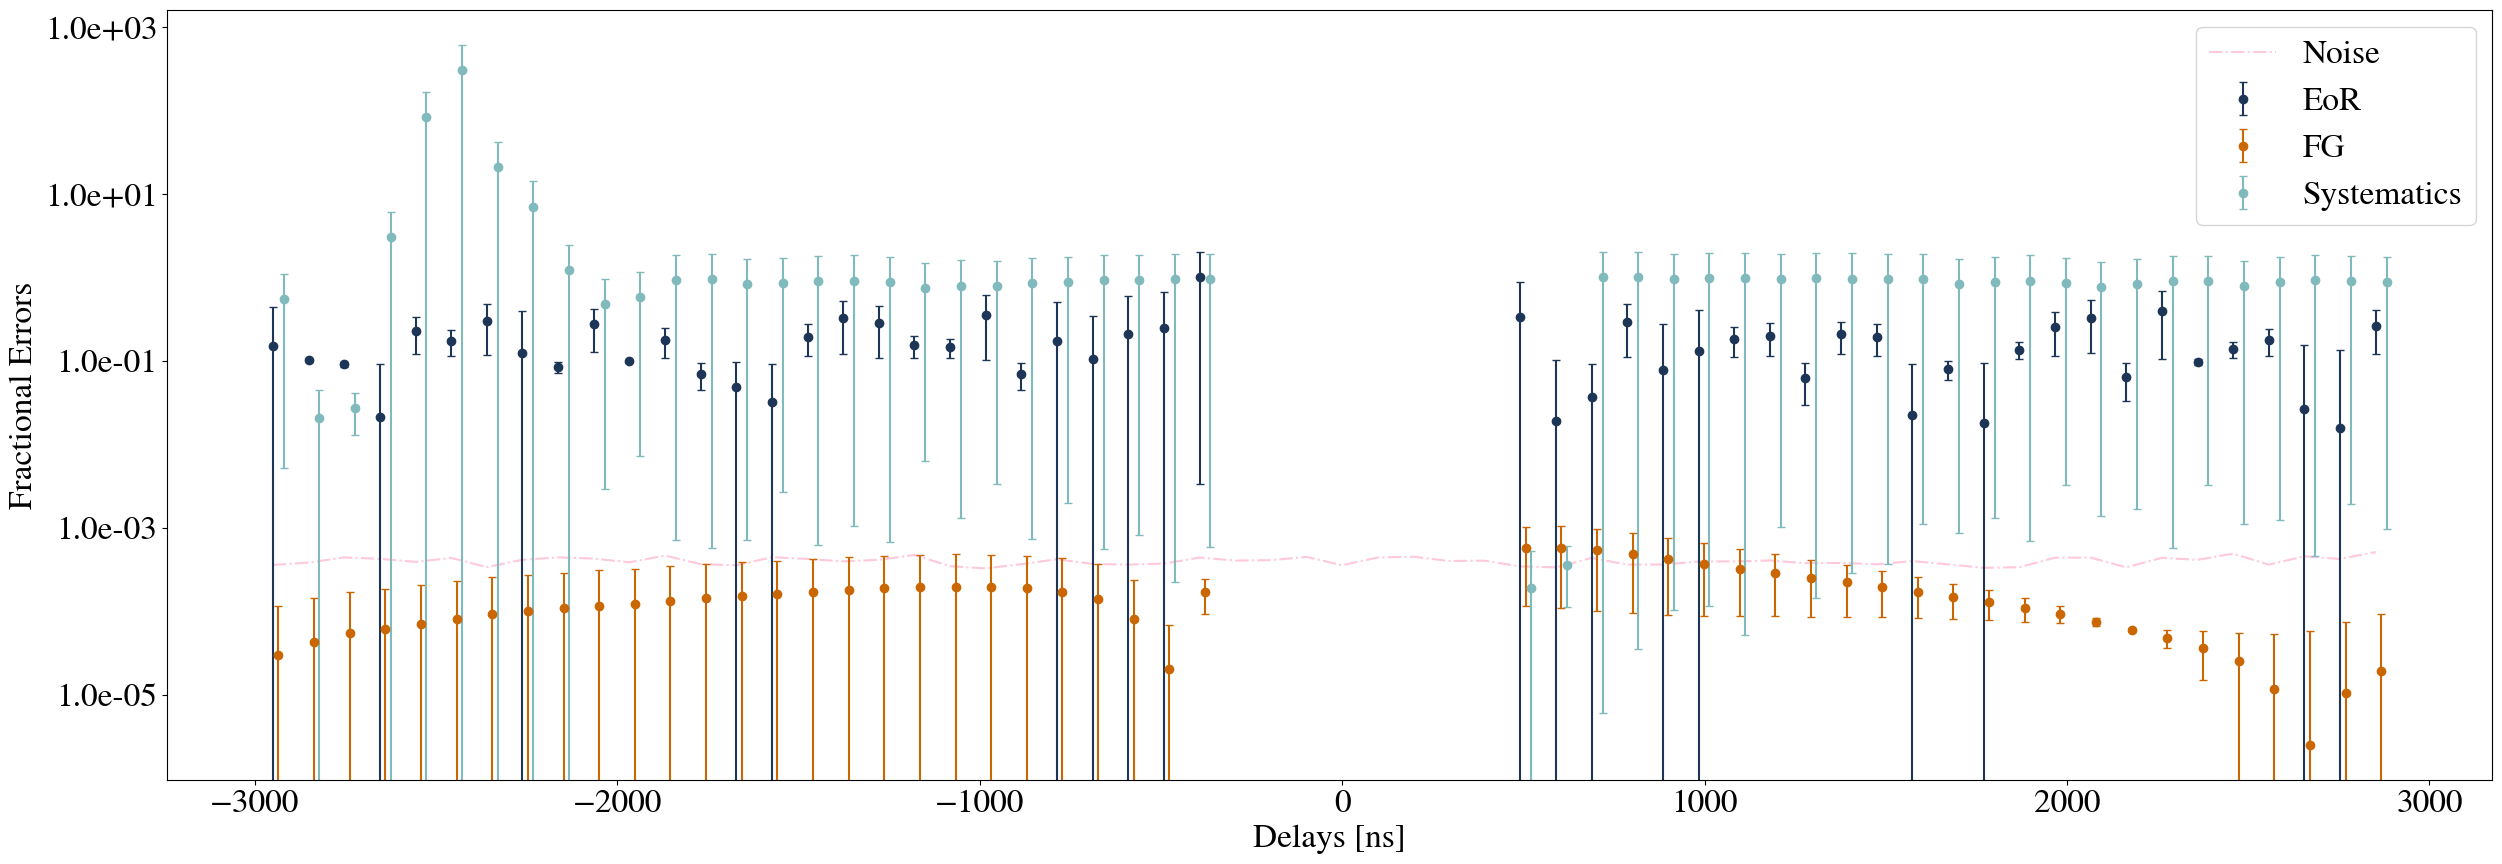

In [16]:
fig, axs = plt.subplots(1, 1, figsize=(30, 10))

data_arr_errs = [
    (eor_pspec_true - ps_sample) / eor_pspec_true,
    (fg_pspec_true  - ps_fg)     / fg_pspec_true,
    (sys_pspec_true - ps_sys)    / sys_pspec_true,
]
plot_arr = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['EoR', 'FG', 'Systematics', 'Noise']

rm   = np.arange(27, 35)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = False

axs.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], label=fig_labels_err[-1])

for i in range(3):
    pa = plot_arr[i][keep]
    da = data_arr_errs[i][:, keep]
    std  = np.std(np.abs(da), axis=0)
    errs = np.vstack((pa - std, std - pa))
    axs.errorbar(
        delays[keep].value + (i * 15), np.abs(pa),
        yerr=np.abs(errs), fmt='o', color=colors[i], label=fig_labels_err[i], capsize=3,
    )
    axs.legend()

axs.set_yscale('log')
axs.set_xlabel('Delays [ns]')
axs.set_ylabel('Fractional Errors')
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
# plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)

---
# Figure 8: Corner plot of b_sys (single case)

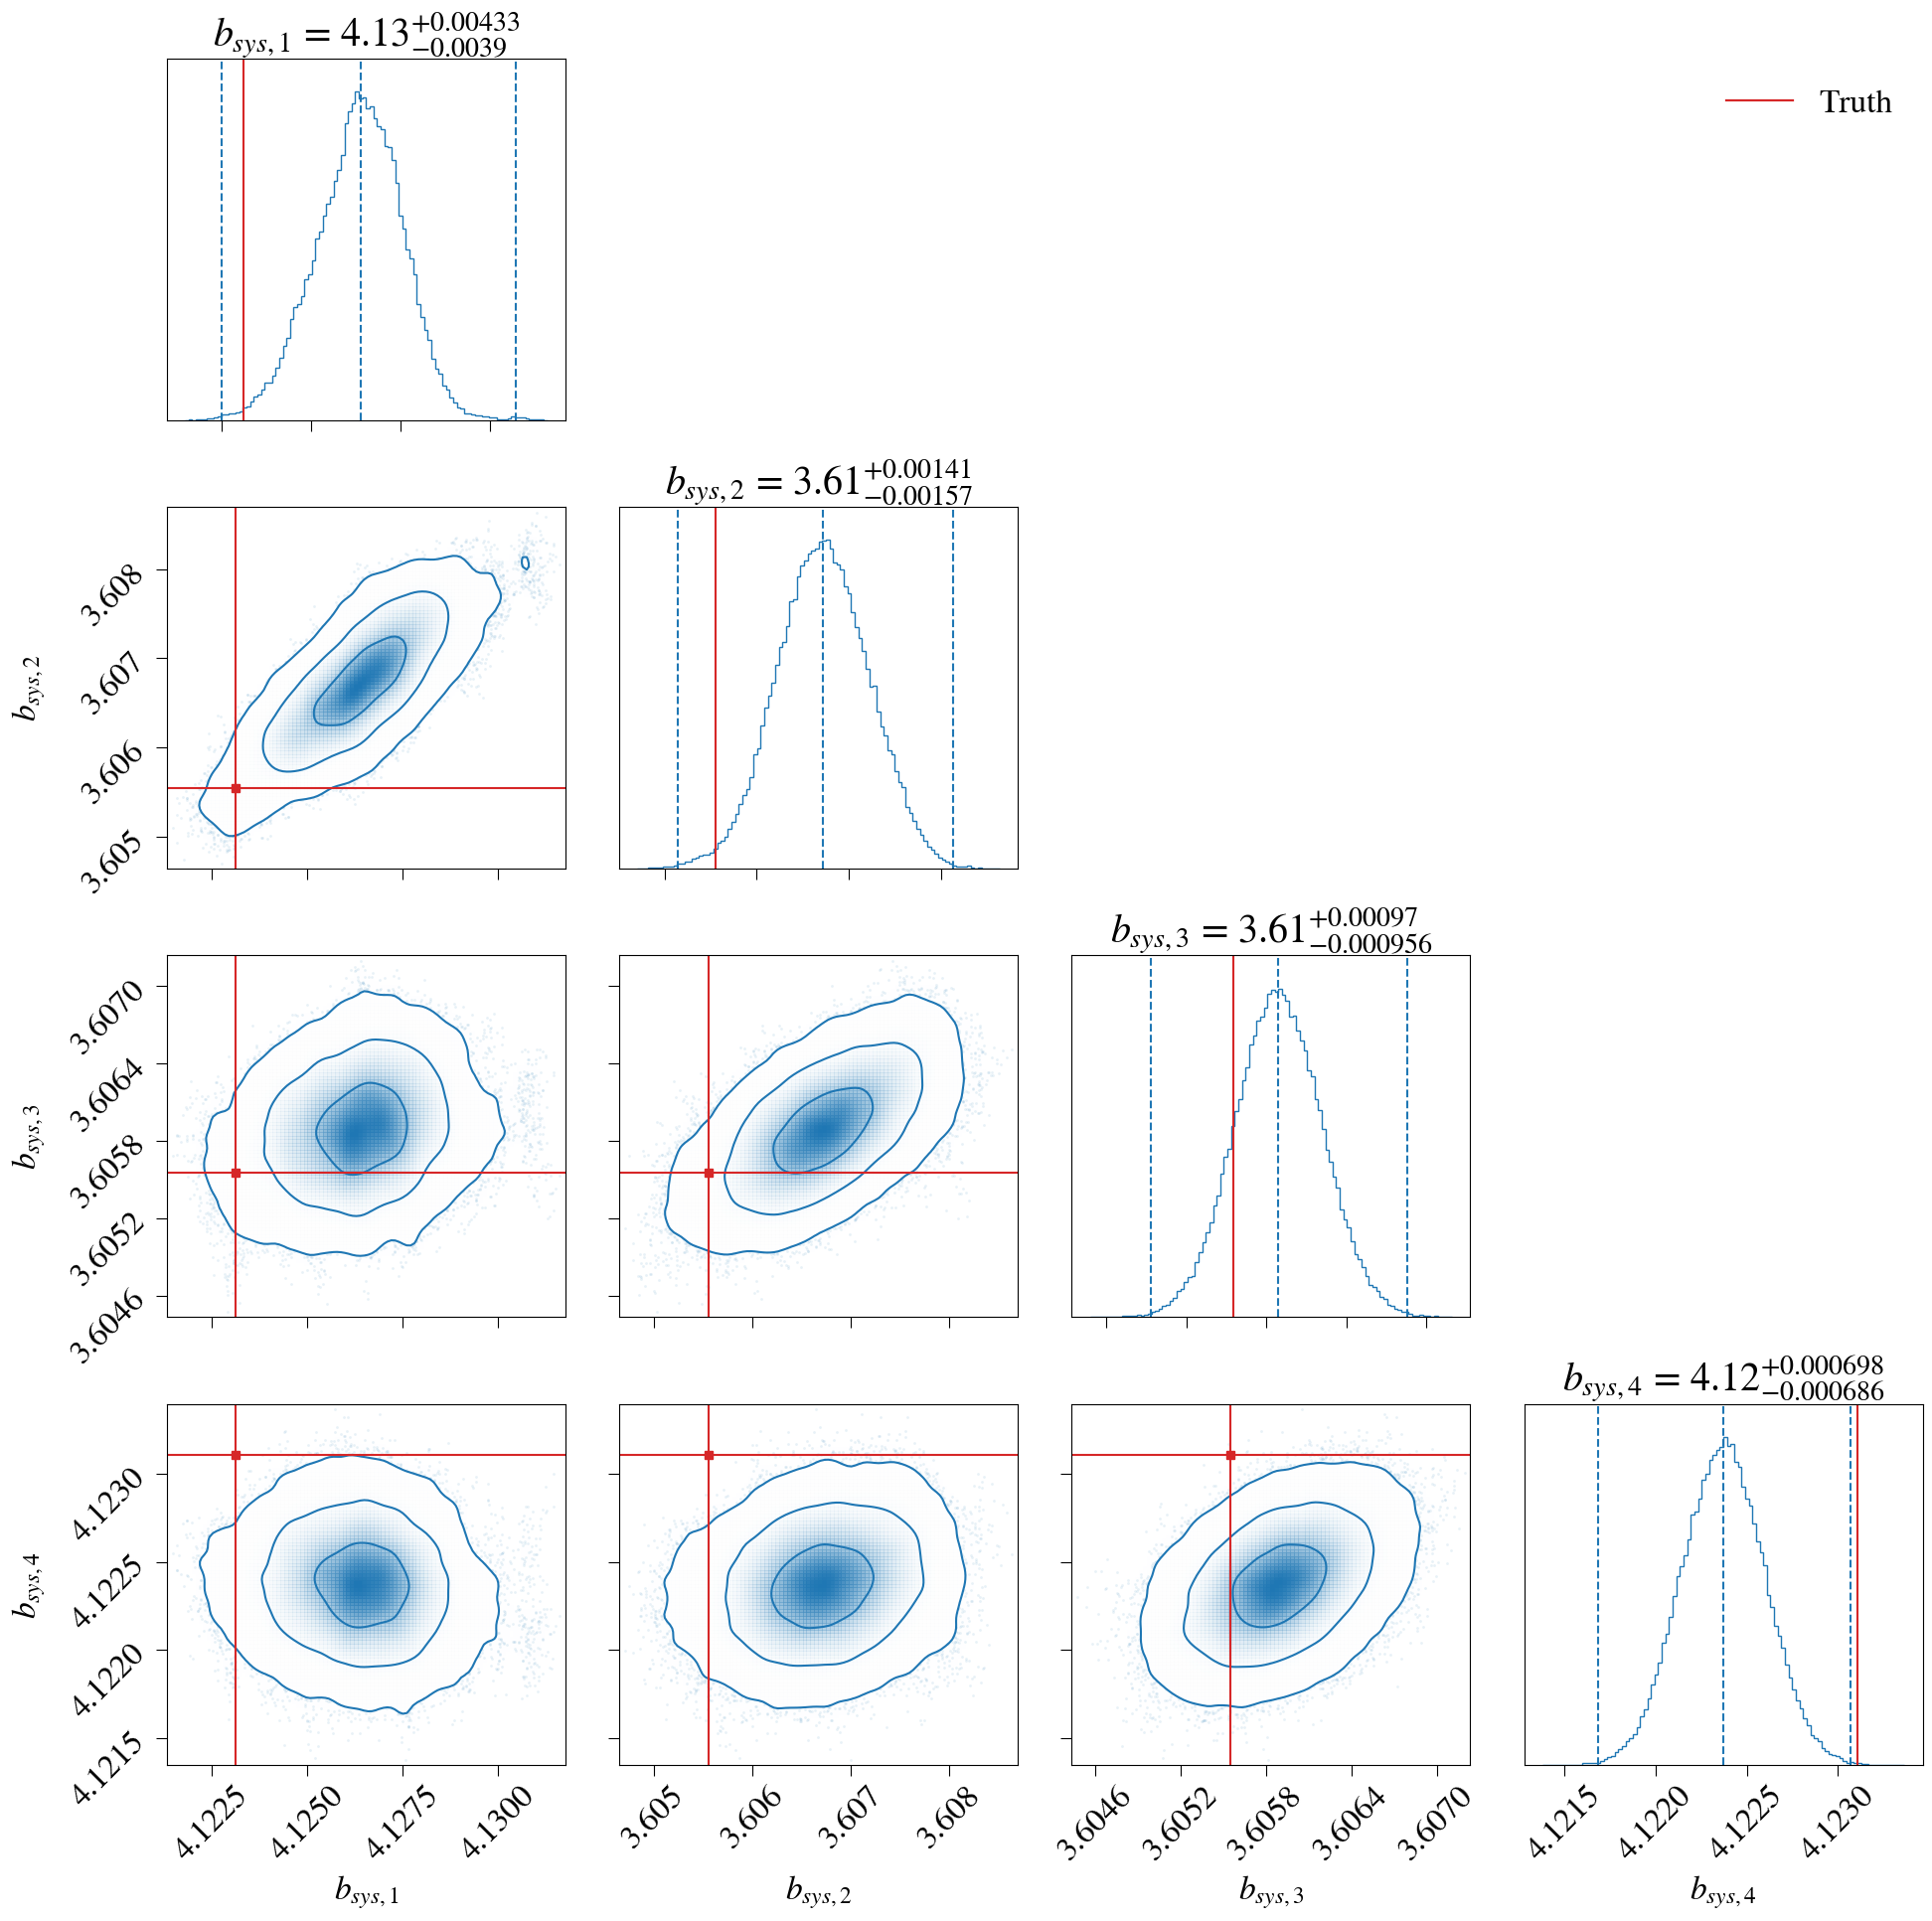

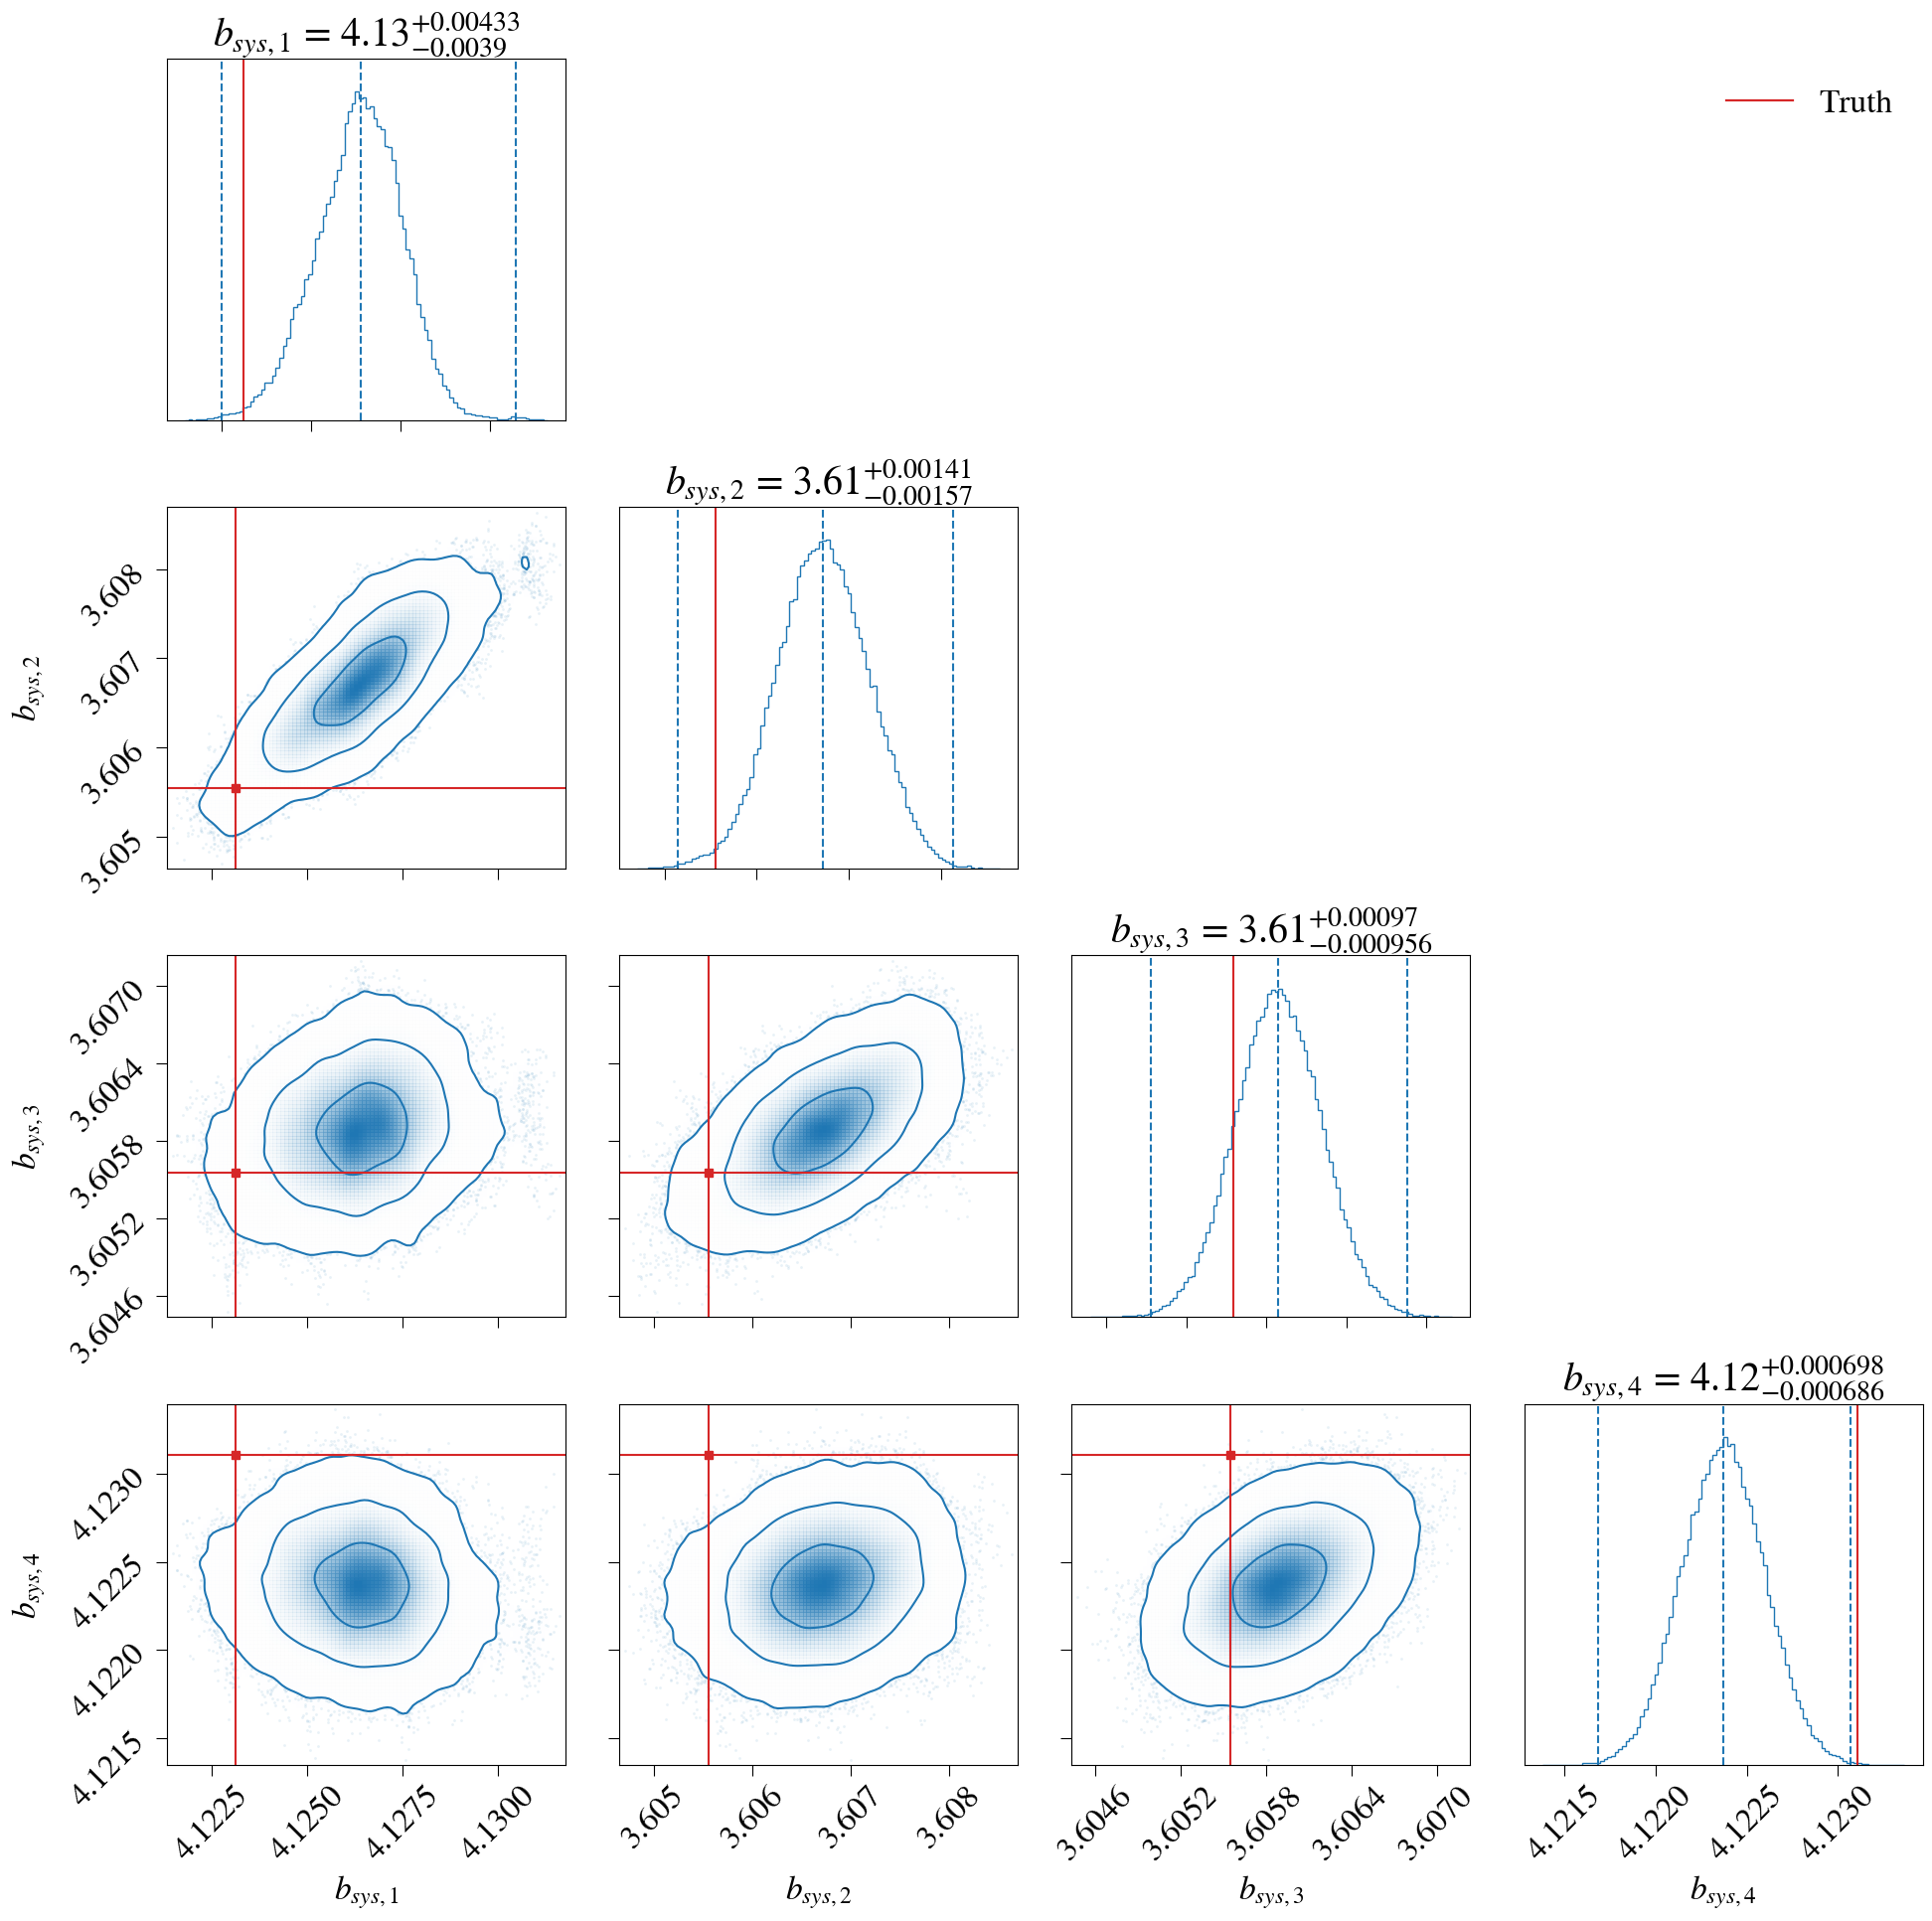

In [17]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for a in ax.flatten():
    a.tick_params(length=8)
corner_plot(
    np.abs(b_sys_gcr),
    truths=np.abs(sys_amps_true),
    labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'],
    fig=fig,
    nsigma=3,
)
# plt.savefig(fig_dir + '/bsys_corner_plot.pdf', bbox_inches='tight', dpi=300)

---
# Figure 9: Systematics fractional error (single case)

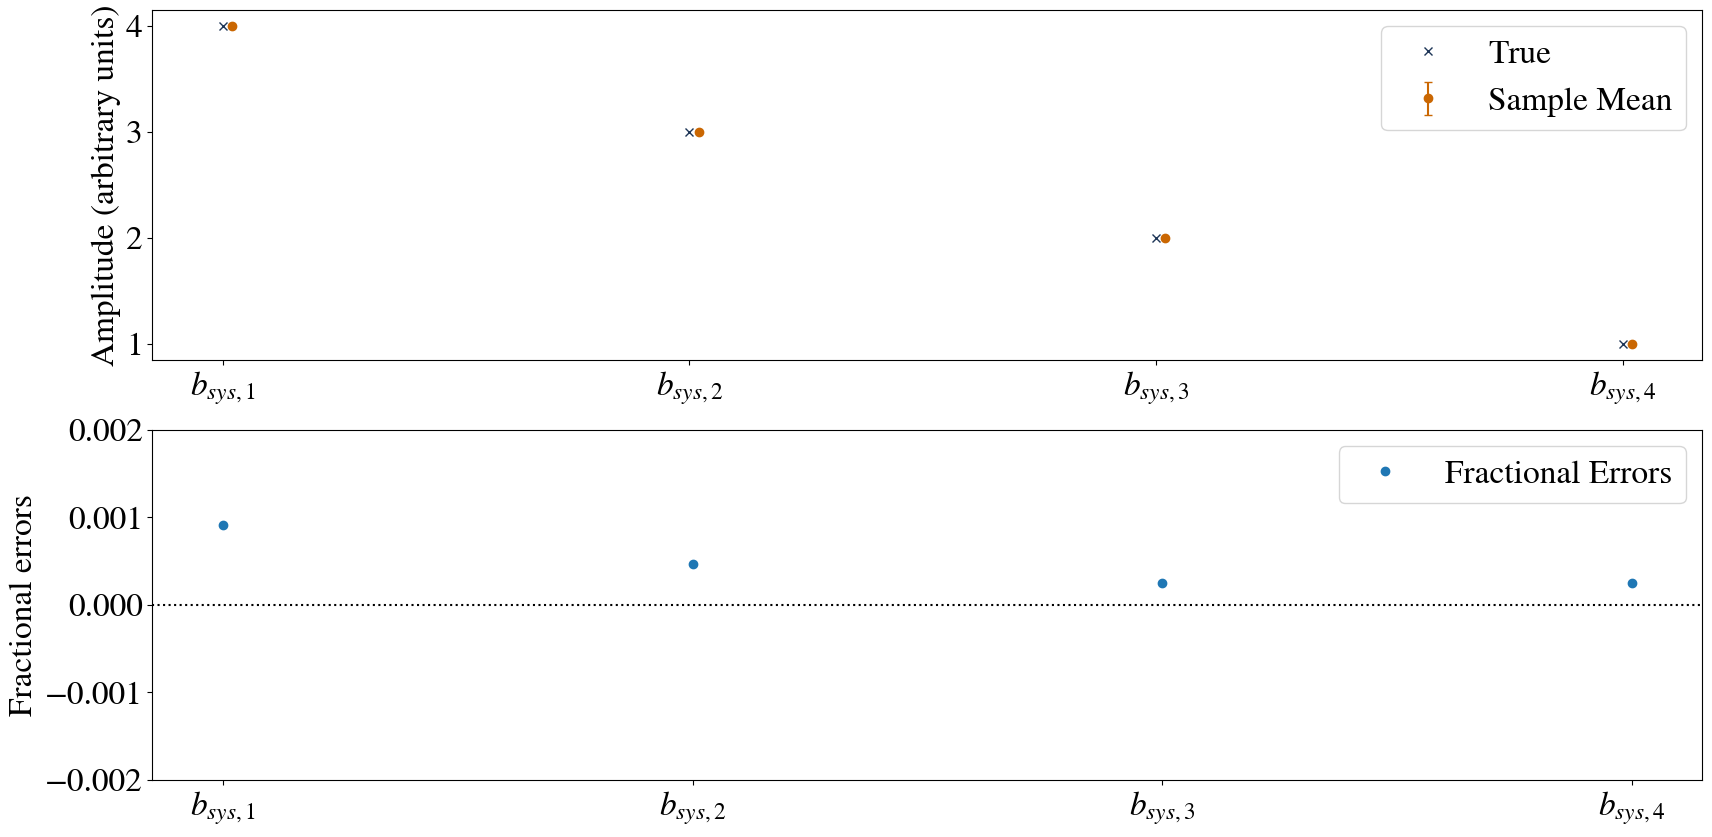

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

errs = np.vstack((
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
))

ax[0].plot(np.imag(sys_amps_true), 'x', c=colors[0], label='True')
ax[0].errorbar(
    [0.02, 1.02, 2.02, 3.02], np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o', yerr=errs, label='Sample Mean', capsize=3, c=colors[1],
)
ax[0].set_ylabel('Amplitude (arbitrary units)')
ax[0].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[0].legend()

res_mean = np.abs(sys_amps_true - b_sys_gcr.mean(axis=0)) / np.abs(sys_amps_true)
ax[1].plot([0, 1, 2, 3], res_mean, 'o', label='Fractional Errors')
ax[1].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[1].axhline(0, c='k', ls='dotted')
ax[1].set_ylabel('Fractional errors')
ax[1].set_ylim(-0.002, 0.002)
ax[1].legend()
# plt.savefig(fig_dir + '/sys_frac_error.pdf', bbox_inches='tight', dpi=300)

---
# Figure 10: Delay power spectra (all cases)

0.3591974718435681
0.3642353021042589
0.333065759900896


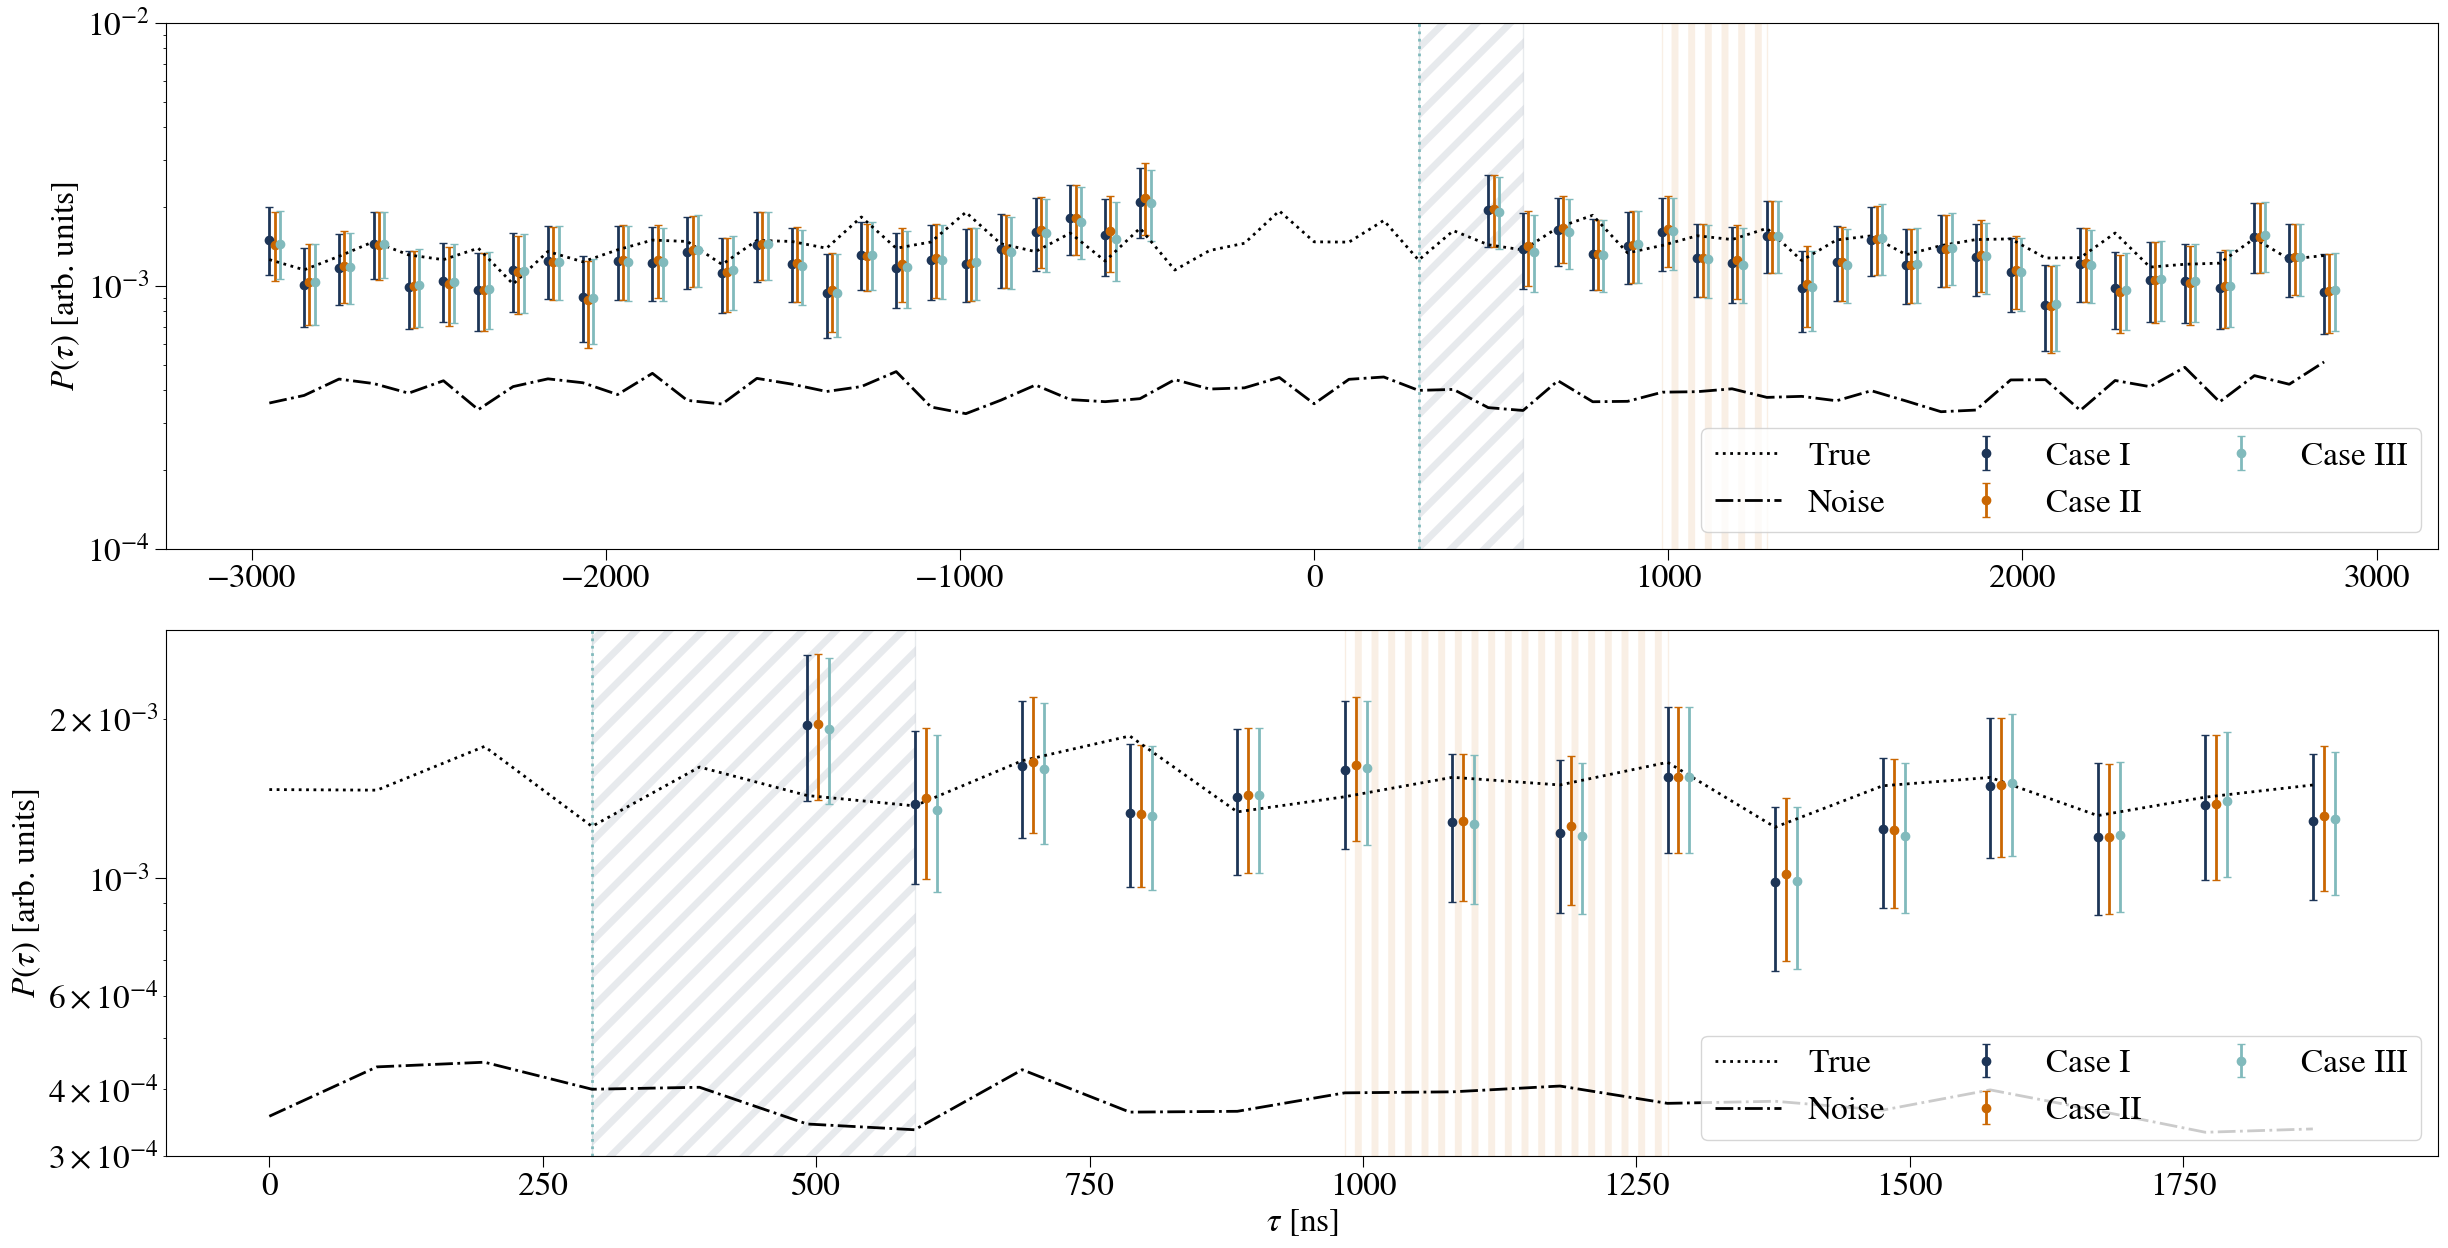

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

fig_labels_dps = ['I', 'II', 'III']
hatches = ['/', '|', '.']

for i, run_version in enumerate(run_version_arr):
    eor_true_i = np.load(result_dir + run_version + '/eor_true.npy')
    ps_sample_i = np.load(result_dir + run_version + '/dps-eor.npy')
    ln_post_i   = np.load(result_dir + run_version + '/ln-post.npy')
    ps_true_i   = calc_ps(eor_true_i[:Ntimes, :Nfreqs])

    sys_delays = delays[np.unique(dl_inds[i]) + int(Nfreqs / 2)].value

    if Nburn > 0:
        ps_sample_i = ps_sample_i[Nburn:]
        ln_post_i   = ln_post_i[Nburn:]

    dps_pwm    = np.average(ps_sample_i, weights=ln_post_i, axis=0)
    percentile = conf_interval / 2 + 50
    dps_ubound = np.percentile(ps_sample_i, percentile,       axis=0)
    dps_lbound = np.percentile(ps_sample_i, 100 - percentile, axis=0)
    dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

    ax[0].errorbar(
        delays.value + i * 15, dps_pwm, yerr=np.abs(dps_err),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )

    x0, x1 = np.min(sys_delays), np.max(sys_delays)
    ax[0].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)
    ax[1].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)

    if i == 2:
        for dl in sys_delays:
            ax[0].axvline(dl, ls='dotted', c=colors[i], lw=2)
            ax[1].axvline(dl, ls='dotted', c=colors[i], lw=2)

    ax[1].errorbar(
        delays[35:50].value + i * 10, dps_pwm[35:50], yerr=np.abs(dps_err[:, 35:50]),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )
    print(max((dps_pwm - ps_true_i) / ps_true_i))

ps_true_ref = calc_ps(np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs])

ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].plot(delays[30:50], ps_true_ref[30:50], 'k:', label='True', lw=2)
ax[1].plot(delays[30:50], calc_ps(n.T)[30:50], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3)
ax[1].set_yscale('log')

ax[0].plot(delays, ps_true_ref, 'k:', label='True', lw=2)
ax[0].plot(delays, calc_ps(n.T), 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-2)
ax[0].set_yscale('log')

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()
# plt.savefig(fig_dir + '/delay_power_spectrum_combined.pdf', bbox_inches='tight', dpi=300)

---
# Table 1: ESS and autocorrelation time

In [20]:
for run_version in run_version_arr:
    print('Case:', run_version)
    b_sys = np.load(result_dir + run_version + '/b-sys.npy')
    taus  = emcee.autocorr.integrated_time(b_sys, c=5, tol=50, quiet=True, has_walkers=False)
    ess   = Niter / taus
    print('\n Taus: {}\nEss:{}\n'.format(taus, ess))

Case: low_dl_fr_0

 Taus: [698.45676808 608.53953469  92.27023448  77.7223783 ]
Ess:[ 143.17278401  164.32786089 1083.77312104 1286.63072583]

Case: high_dl_fr_0

 Taus: [9.04033747 7.49803835 7.59655271 9.23706956]
Ess:[11061.53396499 13336.82162025 13163.8657435  10825.94423975]

Case: low_dl_fr_20

 Taus: [452.66133458 423.27131603 188.2239657   58.67591911]
Ess:[ 220.91570974  236.25508324  531.28197372 1704.27666945]



---
# Figure 11: FG–systematics correlation (all cases)

Foregrounds...


100%|██████████| 100000/100000 [00:16<00:00, 5976.00it/s]


Systematics...


100%|██████████| 100000/100000 [00:37<00:00, 2644.99it/s]


Foregrounds...


...

100%|██████████| 100000/100000 [00:34<00:00, 2935.45it/s]


Foregrounds...


100%|██████████| 100000/100000 [00:16<00:00, 5953.68it/s]


Systematics...


100%|██████████| 100000/100000 [01:23<00:00, 1196.69it/s]


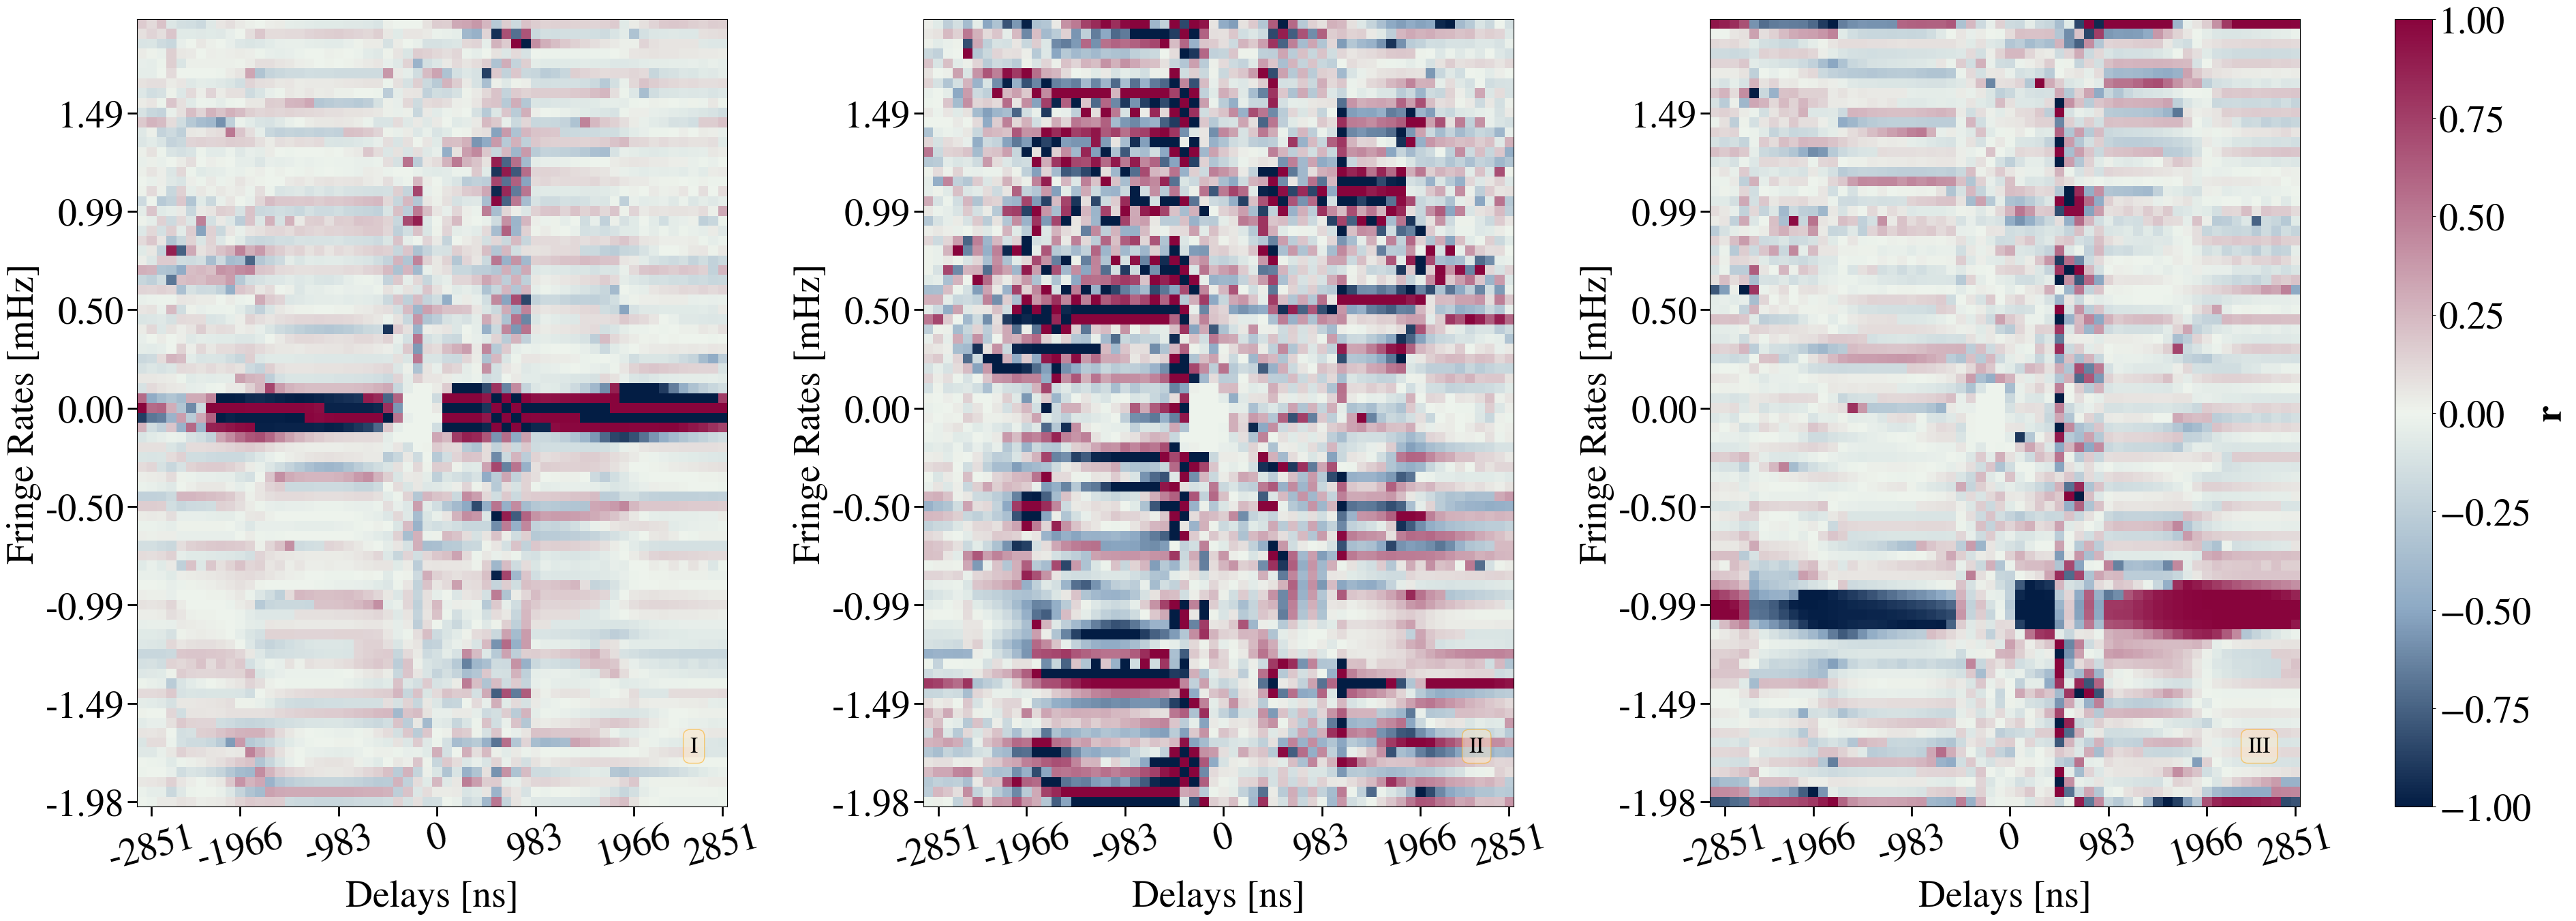

In [21]:
fig = plt.figure(figsize=(45, 15))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    label_mode='all',
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

fig_labels_corr = ['I', 'II', 'III']
for i, run_version in enumerate(run_version_arr):
    fgmodes_i   = np.load(result_dir + run_version + '/fgmodes.npy')
    fg_amps_i   = np.load(result_dir + run_version + '/fg-amps.npy')
    b_sys_i     = np.load(result_dir + run_version + '/b-sys.npy')

    fg_vis_i          = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    delta_g_i         = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    fg_dlfr_i         = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')
    sys_model_dlfr_i  = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')

    print('Foregrounds...')
    for a in tqdm(range(Niter)):
        fg_vis_i[a, :, :]  = (fgmodes_i @ fg_amps_i[a, :].T).T
        fg_dlfr_i[a, :, :] = data_dly_fr(fg_vis_i[a, :, :], freqs * 1e6, lsts, windows='blackman-harris')

    print('Systematics...')
    for a in tqdm(range(Niter)):
        delta_g_i[a, :, :]       = (sys_modes_operator @ b_sys_i[a, :]).reshape([Nfreqs, Ntimes]).T
        sys_model_dlfr_i[a, :, :] = data_dly_fr(1 + delta_g_i[a, :, :], freqs * 1e6, lsts, windows='blackman-harris')

    corr_map = plot_crosscor_pearson(fg_dlfr_i, sys_model_dlfr_i)

    im = axs[i].imshow(corr_map[::-1, :].real, cmap=paper_map, origin='lower', vmin=-1, vmax=1)
    axs[i].text(0.95, 0.07, fig_labels_corr[i], bbox=bbox,
                transform=axs[i].transAxes, horizontalalignment='right')

cbar = axs.cbar_axes[0].colorbar(im)
cbar.set_label(r'$\mathbf{r}$', size=40)
cbar.ax.tick_params(labelsize=40)

for ax in axs:
    ax.set_xlabel('Delays [ns]', fontsize=40)
    ax.set_ylabel('Fringe Rates [mHz]', fontsize=40)
    ax.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=40)
    ax.set_xticks(xticklocs, labels=xticklabels_dl, rotation=15)
    ax.set_yticks(yticklocs, labels=yticklabels_fr)

# plt.savefig(fig_dir + '/fg_sys_corr.pdf', bbox_inches='tight', dpi=300)